In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import h5py
from pathlib import Path
from scipy import stats
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)


In [2]:
MULTI_OMICS_BASE = Path("/Users/bgadmin/Downloads/multiomics_preproc")
CNV_ONLY_BASE    = Path("/Users/bgadmin/Downloads/cnv_preproc_release_v2")
OUT_DIR          = MULTI_OMICS_BASE / "comparison_axe1_vs_axe2"
OUT_FIG          = OUT_DIR / "investigation_figures"
OUT_FIG.mkdir(parents=True, exist_ok=True)

META_FINAL          = MULTI_OMICS_BASE / "meta_final.tsv"
MOFA_SIGNATURES     = MULTI_OMICS_BASE / "subtyping" / "mofa_signatures.tsv"
MOFA_SIGNATURES_ALL = MULTI_OMICS_BASE / "subtyping" / "mofa_signatures_all.tsv"
MOFA_FACTORS        = MULTI_OMICS_BASE / "mofa_factors.parquet"
MOFA_MODEL          = MULTI_OMICS_BASE / "mofa_model.hdf5"
COMPARISON_TABLE    = OUT_DIR / "comparison_final_unified.tsv"

LEIDEN_MOFA_DIR = MULTI_OMICS_BASE / "clustering_leiden_A" / "clusters_by_group"
LEIDEN_CNV_DIR  = CNV_ONLY_BASE / "subtyping_leiden_A" / "clusters_by_root"

# ── Color palette per interpretation ────────────────────────
INTERP_COLORS = {
    "Multi-omic adds value":                         "#2ecc71",
    "Multi-omic adds value — global structure only": "#27ae60",
    "CNV sufficient":                                "#e74c3c",
    "CNV sufficient (reclassified)" :                "#7A1B1B",
    "Neutral — conflicting signals":                 "#f39c12",
    "Neutral — no clear winner":                     "#95a5a6",
    "Too small — unreliable":                        "#bdc3c7",
}
# Interpretations to keep in analyses (exclude unreliable)
KEEP = [
    "Multi-omic adds value",
    "Multi-omic adds value — global structure only",
    "CNV sufficient",
    "Neutral — conflicting signals",
    "Neutral — no clear winner",
]

print("Setup done.")

Setup done.


In [3]:
def compute_cnv_burden(df, dup_cols, del_cols):
    """
    Compute CNV burden per sample = fraction of genes with any alteration.
    Returns a Series indexed like df.
    """
    cnv_matrix = df[dup_cols].values + df[del_cols].values
    n_genes = cnv_matrix.shape[1]
    return pd.Series((cnv_matrix > 0).sum(axis=1) / n_genes, index=df.index)


def compute_freq_matrix(df, feature_cols, cluster_col):
    """
    Compute alteration frequency per cluster.
    Returns DataFrame: rows = features, columns = cluster labels.
    """
    clusters = sorted(df[cluster_col].unique())
    freq = {}
    for cl in clusters:
        mask = df[cluster_col] == cl
        freq[cl] = (df.loc[mask, feature_cols] > 0).mean()
    return pd.DataFrame(freq)


def top_differential_markers(df, feature_cols, cluster_col, top_n=20):
    """
    For each cluster, find features with highest frequency delta
    versus all other clusters combined.
    Returns a DataFrame with columns:
        cluster | feature | freq_cluster | freq_rest | delta | gene_label
    """
    clusters = sorted(df[cluster_col].unique())
    records = []
    for cl in clusters:
        mask = df[cluster_col] == cl
        freq_cl   = (df.loc[mask,  feature_cols] > 0).mean()
        freq_rest = (df.loc[~mask, feature_cols] > 0).mean()
        delta     = freq_cl - freq_rest
        top_idx   = delta.abs().nlargest(top_n).index
        for feat in top_idx:
            records.append({
                "cluster":      cl,
                "feature":      feat,
                "freq_cluster": round(freq_cl[feat], 3),
                "freq_rest":    round(freq_rest[feat], 3),
                "delta":        round(delta[feat], 3),
                "gene_label":   feat.replace("cnv_", "")
                                    .replace("__dup", " dup")
                                    .replace("__del", " del"),
            })
    return pd.DataFrame(records)


def top_global_markers(df, feature_cols, top_n=20):
    """
    Return the top_n most frequently altered features across all samples.
    Returns a DataFrame with columns: feature | frequency | gene_label
    """
    freq = (df[feature_cols] > 0).mean().sort_values(ascending=False).head(top_n)
    result = freq.reset_index()
    result.columns = ["feature", "frequency"]
    result["gene_label"] = (
        result["feature"]
        .str.replace("cnv_", "", regex=False)
        .str.replace("__dup", " dup", regex=False)
        .str.replace("__del", " del", regex=False)
    )
    return result


def get_top_loadings(df_W, factor, top_n=15):
    """
    Return top_n features with highest absolute MOFA loading for a given factor.
    Returns a DataFrame with columns: feature | loading | abs_loading
    """
    s = df_W[factor].copy()
    top_idx = s.abs().nlargest(top_n).index
    result = s.loc[top_idx].reset_index()
    result.columns = ["feature", "loading"]
    result["abs_loading"] = result["loading"].abs()
    return result.sort_values("abs_loading", ascending=False)


def safe_name(s):
    """Convert a group name to a filesystem-safe string."""
    return s.replace("/", "_").replace(" ", "_").replace("(", "").replace(")", "")


print("Utility functions defined.")

Utility functions defined.


### Loading & Validation

In [4]:
df_comp = pd.read_csv(COMPARISON_TABLE, sep="\t")
print(f"comparison_table     : {df_comp.shape}")
print(df_comp["interpretation"].value_counts())

comparison_table     : (18, 15)
interpretation
CNV sufficient                                   5
Too small — unreliable                           4
Neutral — no clear winner                        4
Multi-omic adds value                            3
Multi-omic adds value — global structure only    1
Neutral — conflicting signals                    1
Name: count, dtype: int64


In [5]:
# Meta final (samples × features) 
df_meta = pd.read_csv(META_FINAL, sep="\t", low_memory=False)
print(f"meta_final           : {df_meta.shape}")

# Identify CNV columns by type
dup_cols  = [c for c in df_meta.columns if c.endswith("__dup")]
del_cols  = [c for c in df_meta.columns if c.endswith("__del")]
hldup_cols = [c for c in df_meta.columns if c.endswith("__hldup")]
hldel_cols = [c for c in df_meta.columns if c.endswith("__hldel")]
alt_cols  = dup_cols + del_cols   # used throughout for burden & markers

print(f"  dup cols   : {len(dup_cols)}")
print(f"  del cols   : {len(del_cols)}")
print(f"  unique genes: {len(dup_cols)}")
print(f"  NaN in CNV : {df_meta[alt_cols].isnull().sum().sum()}")

meta_final           : (9592, 10184)
  dup cols   : 1301
  del cols   : 1301
  unique genes: 1301
  NaN in CNV : 0


In [6]:
# MOFA signatures (significant factors only)
df_mofa_sig = pd.read_csv(MOFA_SIGNATURES, sep="\t")
df_mofa_sig = df_mofa_sig.merge(
    df_comp[["cancer_group", "interpretation"]],
    on="cancer_group", how="left"
)
df_mofa_sig["disc_power"] = (df_mofa_sig["auc"] - 0.5).abs()
print(f"mofa_signatures      : {df_mofa_sig.shape}")
print(f"  dominant omics     : {df_mofa_sig['dominant_omic'].value_counts().to_dict()}")

mofa_signatures      : (504, 13)
  dominant omics     : {'Meth': 268, 'RNA': 121, 'CNV': 115}


In [7]:
# MOFA loadings W from HDF5 
with h5py.File(MOFA_MODEL, "r") as f:
    features_cnv  = [x.decode() for x in f["features/CNV"][:]]
    features_meth = [x.decode() for x in f["features/Meth"][:]]
    features_rna  = [x.decode() for x in f["features/RNA"][:]]
    W_cnv  = f["expectations/W/CNV"][:]
    W_meth = f["expectations/W/Meth"][:]
    W_rna  = f["expectations/W/RNA"][:]

n_factors    = W_cnv.shape[0]
factor_names = [f"Factor{i+1}" for i in range(n_factors)]

df_W_cnv  = pd.DataFrame(W_cnv.T,  index=features_cnv,  columns=factor_names)
df_W_meth = pd.DataFrame(W_meth.T, index=features_meth, columns=factor_names)
df_W_rna  = pd.DataFrame(W_rna.T,  index=features_rna,  columns=factor_names)

W_map = {"CNV": df_W_cnv, "Meth": df_W_meth, "RNA": df_W_rna}

print(f"MOFA model loaded    : {n_factors} factors")
print(f"  CNV features : {len(features_cnv)}")
print(f"  Meth features: {len(features_meth)}")
print(f"  RNA features : {len(features_rna)}")

MOFA model loaded    : 20 factors
  CNV features : 5128
  Meth features: 1171
  RNA features : 1301


In [8]:
# Leiden clusters — MOFA groups 
MOFA_CLUSTER_FILES = {
    "Brain (C71)":                    "Brain_C71_clusters_leiden_cpm.parquet",
    "Male genital (C60-C63)":         "Male_genital_C60-C63_clusters_leiden_cpm.parquet",
    #"Esophagus/Intestine (C15-C26)":  "Esophagus_Intestine_C15-C26_clusters_leiden_cpm.parquet",
    "Thyroid/Endocrine (C73-C75)":    "Thyroid_Endocrine_C73-C75_clusters_leiden_cpm.parquet",
    "Urinary (C64-C68)":              "Urinary_C64-C68_clusters_leiden_cpm.parquet",
}

leiden_mofa = {}
for grp, fname in MOFA_CLUSTER_FILES.items():
    path = LEIDEN_MOFA_DIR / fname
    if path.exists():
        df_cl = pd.read_parquet(path)
        leiden_mofa[grp] = df_cl[df_cl["cluster"] != -1].copy()
        print(f"  {grp:40s} clusters: {sorted(df_cl['cluster'].unique())}")
    else:
        print(f"  MISSING: {fname}")

# Leiden clusters — CNV-based groups 
# CNV sufficient (original classification)
CNV_SUFFICIENT_STRICT = [
    "Lung (C30-C39)",
    "Liver/Biliary (C22-C24)",
    "Colorectal (C18-C20)",
    "Lymph nodes (C77)",
    "Breast (C50)",
]

# Reclassified as CNV sufficient post-hoc:
# - C25 (Pancreas): 0 significant MOFA factors, 3/3 metrics favor CNV
# - Head & Neck (C00-C14): 0 significant MOFA factors, 3/3 metrics favor CNV
CNV_SUFFICIENT_RECLASSIFIED = [
    "Head & Neck (C00-C14)",
    "C25",
    "Esophagus_SCC (C15)",    
    "Esophagus_ADENO (C15)",
]

CNV_SUFFICIENT_ALL = CNV_SUFFICIENT_STRICT + CNV_SUFFICIENT_RECLASSIFIED

CNV_CLUSTER_FILES = {
    "Lung (C30-C39)":          "C30_C39_clusters_leiden_cpm.parquet",
    "Liver/Biliary (C22-C24)": "C22_C24_clusters_leiden_cpm.parquet",
    "Colorectal (C18-C20)":    "C18_C20_clusters_leiden_cpm.parquet",
    "Lymph nodes (C77)":       "C77_clusters_leiden_cpm.parquet",
    "Breast (C50)":            "C50_clusters_leiden_cpm.parquet",
    "Head & Neck (C00-C14)":   "C00_C14_clusters_leiden_cpm.parquet",
    "C25":                     "C25_clusters_leiden_cpm.parquet",
    "Esophagus_SCC (C15)":     "C15_SCC_clusters_leiden_cpm.parquet",  
    "Esophagus_ADENO (C15)":   "C15_ADENO_clusters_leiden_cpm.parquet",
}

# Neutral groups — have CNV Leiden files but no clear winner
CNV_NEUTRAL_FILES = {
    "Gynecologic (C51-C58)": "C51_C58_clusters_leiden_cpm.parquet",
    "SoftTissue (C49)":      "C49_clusters_leiden_cpm.parquet",
    "C16":                   "C16_clusters_leiden_cpm.parquet",
}

leiden_cnv = {}
for grp, fname in CNV_CLUSTER_FILES.items():
    path = LEIDEN_CNV_DIR / fname
    if path.exists():
        df_cl = pd.read_parquet(path)
        leiden_cnv[grp] = df_cl[df_cl["cluster"] != -1].copy()
        tag = "(reclassified)" if grp in CNV_SUFFICIENT_RECLASSIFIED else "(strict)"
        print(f"  {grp:40s} {tag:16s} clusters: {sorted(df_cl['cluster'].unique())}")
    else:
        print(f"  MISSING: {fname}")

leiden_cnv_neutral = {}
for grp, fname in CNV_NEUTRAL_FILES.items():
    path = LEIDEN_CNV_DIR / fname
    if path.exists():
        df_cl = pd.read_parquet(path)
        leiden_cnv_neutral[grp] = df_cl[df_cl["cluster"] != -1].copy()
        print(f"  {grp:40s} (neutral)         clusters: {sorted(df_cl['cluster'].unique())}")
    else:
        print(f"  MISSING: {fname}")

  Brain (C71)                              clusters: [np.int64(0), np.int64(1)]
  Male genital (C60-C63)                   clusters: [np.int64(0), np.int64(1)]
  Thyroid/Endocrine (C73-C75)              clusters: [np.int64(-1), np.int64(0), np.int64(1)]
  Urinary (C64-C68)                        clusters: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]
  Lung (C30-C39)                           (strict)         clusters: [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
  Liver/Biliary (C22-C24)                  (strict)         clusters: [np.int64(-1), np.int64(0)]
  Colorectal (C18-C20)                     (strict)         clusters: [np.int64(-1), np.int64(0), np.int64(1)]
  Lymph nodes (C77)                        (strict)         clusters: [np.int64(-1), np.int64(0)]
  Breast (C50)                             (strict)         clusters: [np.int64(-1), np.int64(0), np.int

In [9]:
# Data health summary 
print("DATA HEALTH REPORT")

print(f"  meta_final               : {df_meta.shape}")
print(f"  comparison_table         : {df_comp.shape}")
print(f"  mofa_signatures (sig)    : {df_mofa_sig.shape}")
print(f"  CNV genes (dup+del)      : {len(dup_cols)} genes × 2 types")
print(f"  MOFA factors             : {n_factors}")
print(f"  MOFA groups (leiden)     : {len(leiden_mofa)}")
print(f"  CNV groups  (leiden)     : {len(leiden_cnv)}")
print(f"\n  Interpretation labels:")
for interp, n in df_comp["interpretation"].value_counts().items():
    print(f"    {interp:50s} n={n}")
print("\nReady.")

DATA HEALTH REPORT
  meta_final               : (9592, 10184)
  comparison_table         : (18, 15)
  mofa_signatures (sig)    : (504, 13)
  CNV genes (dup+del)      : 1301 genes × 2 types
  MOFA factors             : 20
  MOFA groups (leiden)     : 4
  CNV groups  (leiden)     : 7

  Interpretation labels:
    CNV sufficient                                     n=5
    Too small — unreliable                             n=4
    Neutral — no clear winner                          n=4
    Multi-omic adds value                              n=3
    Multi-omic adds value — global structure only      n=1
    Neutral — conflicting signals                      n=1

Ready.


### CNV BURDEN — GLOBAL VIEW

In [10]:
# Compute CNV burden per sample 
df_meta["cnv_burden"] = compute_cnv_burden(df_meta, dup_cols, del_cols)

print("CNV burden stats (all samples):")
print(df_meta["cnv_burden"].describe().round(3))

CNV burden stats (all samples):
count    9592.000
mean        0.271
std         0.219
min         0.000
25%         0.089
50%         0.224
75%         0.422
max         0.981
Name: cnv_burden, dtype: float64


/var/folders/35/df9f7vc96sv9r7fc27r5csp40000gn/T/ipykernel_91129/268041900.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_meta["cnv_burden"] = compute_cnv_burden(df_meta, dup_cols, del_cols)


In [11]:
# Attach interpretation label to each sample 
df_burden = (
    df_meta[["biosample_id", "cancer_group", "cnv_burden"]]
    .merge(df_comp[["cancer_group", "interpretation"]], on="cancer_group", how="left")
)

# Fix interpretation for reclassified groups
# (df_comp still has their original label, we override here)
df_burden.loc[
    df_burden["cancer_group"].isin(CNV_SUFFICIENT_RECLASSIFIED),
    "interpretation"
] = "CNV sufficient (reclassified)"

# Keep only interpretable groups (exclude "Too small — unreliable")
KEEP_UPDATED = KEEP + ["CNV sufficient (reclassified)"]
df_burden_filt = df_burden[df_burden["interpretation"].isin(KEEP_UPDATED)].copy()

print(f"Samples with interpretation label : {len(df_burden_filt)}")
print(df_burden_filt["interpretation"].value_counts())

Samples with interpretation label : 8749
interpretation
CNV sufficient                                   3471
Multi-omic adds value                            2471
Neutral — no clear winner                        1532
Multi-omic adds value — global structure only    1110
CNV sufficient (reclassified)                     165
Name: count, dtype: int64


/var/folders/35/df9f7vc96sv9r7fc27r5csp40000gn/T/ipykernel_91129/2133008989.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/35/df9f7vc96sv9r7fc27r5csp40000gn/T/ipykernel_91129/2133008989.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


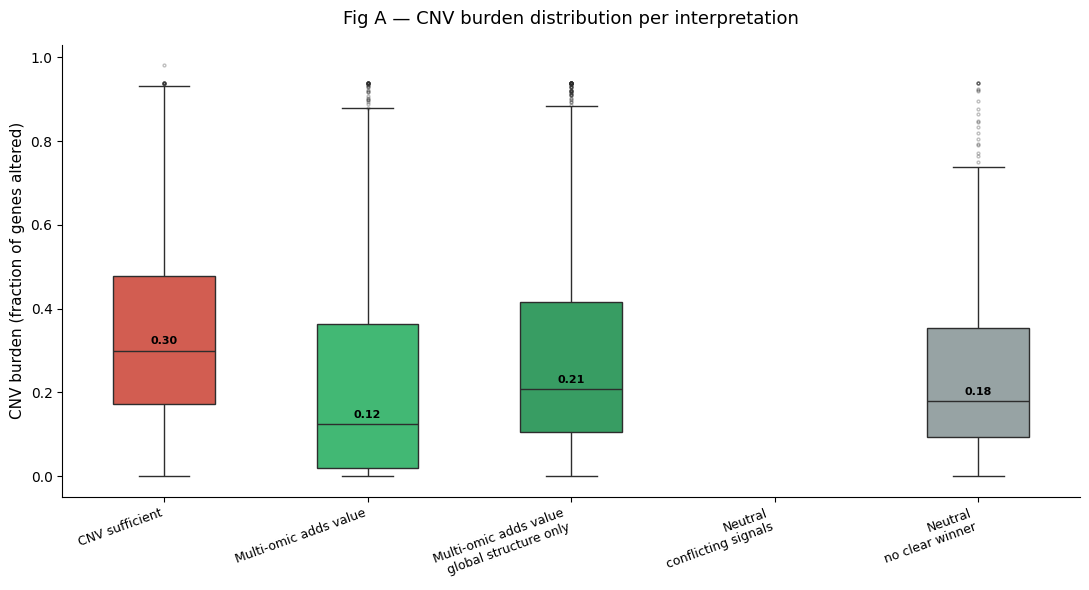

In [12]:
# Burden distribution per interpretation 
INTERP_ORDER = [
    "CNV sufficient",
    "Multi-omic adds value",
    "Multi-omic adds value — global structure only",
    "Neutral — conflicting signals",
    "Neutral — no clear winner",
]

fig, ax = plt.subplots(figsize=(11, 6))
sns.boxplot(
    data=df_burden_filt,
    x="interpretation",
    y="cnv_burden",
    order=INTERP_ORDER,
    palette=INTERP_COLORS,
    width=0.5,
    flierprops=dict(marker="o", markersize=2, alpha=0.3),
    ax=ax,
)

# Annotate medians
for i, interp in enumerate(INTERP_ORDER):
    med = df_burden_filt.loc[
        df_burden_filt["interpretation"] == interp, "cnv_burden"
    ].median()
    ax.text(i, med + 0.01, f"{med:.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_title("Fig A — CNV burden distribution per interpretation", fontsize=13, pad=15)
ax.set_xlabel("")
ax.set_ylabel("CNV burden (fraction of genes altered)", fontsize=11)
ax.set_xticklabels(
    [l.get_text().replace(" — ", "\n") for l in ax.get_xticklabels()],
    rotation=20, ha="right", fontsize=9,
)
sns.despine()
plt.tight_layout()
plt.savefig(OUT_FIG / "fig_A_cnv_burden_by_interpretation.png", dpi=150, bbox_inches="tight")
plt.show()

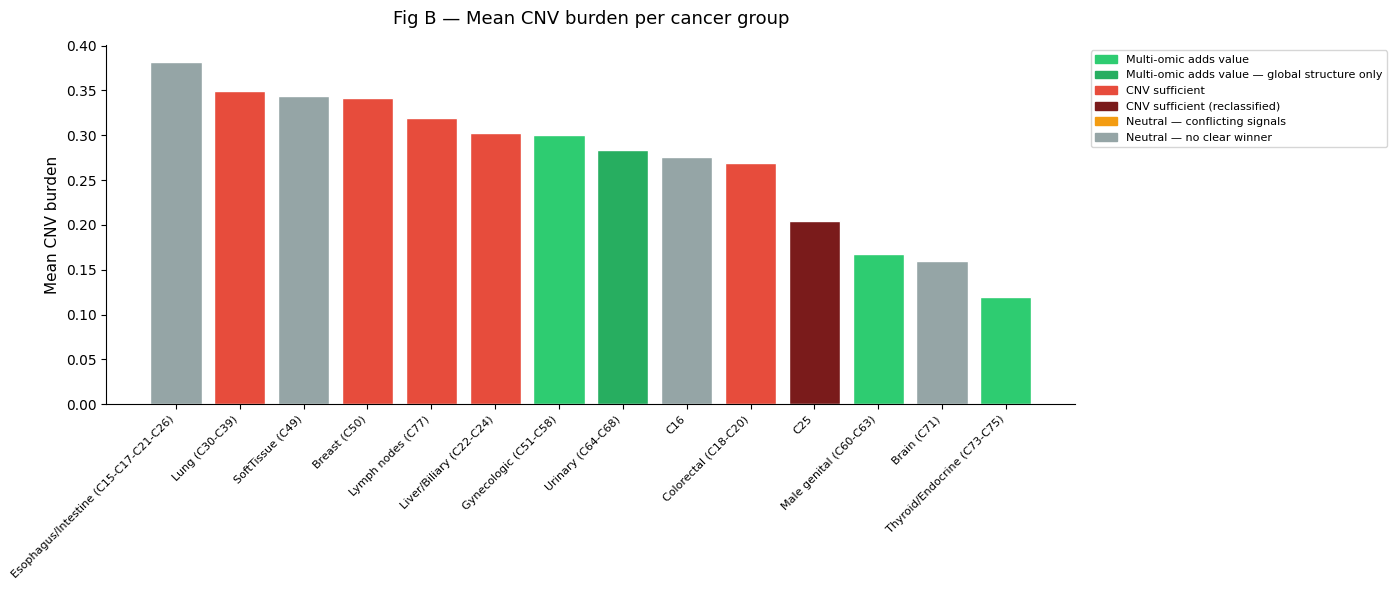

In [13]:
#  Mean burden per cancer group 
burden_by_group = (
    df_burden_filt
    .groupby(["cancer_group", "interpretation"])["cnv_burden"]
    .agg(mean="mean", median="median", n="count")
    .reset_index()
    .sort_values("mean", ascending=False)
)

colors = [INTERP_COLORS.get(i, "#cccccc") for i in burden_by_group["interpretation"]]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(
    range(len(burden_by_group)),
    burden_by_group["mean"],
    color=colors,
    edgecolor="white",
)

ax.set_xticks(range(len(burden_by_group)))
ax.set_xticklabels(burden_by_group["cancer_group"], rotation=45, ha="right", fontsize=8)
ax.set_title("Fig B — Mean CNV burden per cancer group", fontsize=13, pad=15)
ax.set_ylabel("Mean CNV burden", fontsize=11)

patches = [
    mpatches.Patch(color=v, label=k)
    for k, v in INTERP_COLORS.items()
    if k in KEEP_UPDATED
]
ax.legend(handles=patches, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
sns.despine()
plt.tight_layout()
plt.savefig(OUT_FIG / "fig_B_cnv_burden_per_group.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Statistical test — CNV sufficient vs Multi-omic 
cnv_suff_burden = df_burden_filt.loc[
    df_burden_filt["interpretation"] == "CNV sufficient", "cnv_burden"
]
mofa_val_burden = df_burden_filt.loc[
    df_burden_filt["interpretation"] == "Multi-omic adds value", "cnv_burden"
]

u_stat, p_val = stats.mannwhitneyu(cnv_suff_burden, mofa_val_burden, alternative="greater")

print("Mann-Whitney U — CNV sufficient > Multi-omic adds value")
print(f"  U statistic : {u_stat:.0f}")
print(f"  p-value     : {p_val:.2e}")
print(f"  Median CNV sufficient      : {cnv_suff_burden.median():.3f}")
print(f"  Median Multi-omic adds value: {mofa_val_burden.median():.3f}")

Mann-Whitney U — CNV sufficient > Multi-omic adds value
  U statistic : 5763249
  p-value     : 1.06e-113
  Median CNV sufficient      : 0.300
  Median Multi-omic adds value: 0.125


In [15]:
#  Summary table 
print(
    burden_by_group[["cancer_group", "interpretation", "mean", "median", "n"]]
    .to_string(index=False)
)

                         cancer_group                                interpretation     mean   median    n
Esophagus/Intestine (C15-C17-C21-C26)                     Neutral — no clear winner 0.381787 0.371253  193
                       Lung (C30-C39)                                CNV sufficient 0.349317 0.334743 1302
                     SoftTissue (C49)                     Neutral — no clear winner 0.343319 0.323213  196
                         Breast (C50)                                CNV sufficient 0.341644 0.309762  969
                    Lymph nodes (C77)                                CNV sufficient 0.319803 0.277479  237
              Liver/Biliary (C22-C24)                                CNV sufficient 0.302419 0.267102  398
                Gynecologic (C51-C58)                         Multi-omic adds value 0.299780 0.284397 1135
                    Urinary (C64-C68) Multi-omic adds value — global structure only 0.284084 0.207533 1110
                                  C16

In [16]:
# CNV burden variance between clusters 
# what matters is not absolute burden but whether
# CNV burden DIFFERS between clusters (= is discriminant).
# A group can have high global burden but still need multi-omics
# if that burden is homogeneous across subtypes (e.g. Esophagus).

records = []

# CNV sufficient groups
for grp, df_cl in leiden_cnv.items():
    df_grp = df_meta[df_meta["cancer_group"] == grp][
        ["biosample_id", "cnv_burden"]
    ].merge(df_cl[["biosample_id", "cluster"]], on="biosample_id", how="inner")

    if df_grp["cluster"].nunique() < 2:
        between_var = 0.0
    else:
        cluster_means = df_grp.groupby("cluster")["cnv_burden"].mean()
        between_var   = cluster_means.var()

    interp = df_comp.loc[df_comp["cancer_group"] == grp, "interpretation"].values
    records.append({
        "cancer_group":   grp,
        "global_burden":  df_grp["cnv_burden"].mean(),
        "between_cluster_var": between_var,
        "n_clusters":     df_grp["cluster"].nunique(),
        "interpretation": interp[0] if len(interp) else "CNV sufficient",
    })

# Multi-omic groups
for grp, df_cl in leiden_mofa.items():
    df_grp = df_meta[df_meta["cancer_group"] == grp][
        ["biosample_id", "cnv_burden"]
    ].merge(df_cl[["biosample_id", "cluster"]], on="biosample_id", how="inner")

    if df_grp["cluster"].nunique() < 2:
        between_var = 0.0
    else:
        cluster_means = df_grp.groupby("cluster")["cnv_burden"].mean()
        between_var   = cluster_means.var()

    interp = df_comp.loc[df_comp["cancer_group"] == grp, "interpretation"].values
    records.append({
        "cancer_group":   grp,
        "global_burden":  df_grp["cnv_burden"].mean(),
        "between_cluster_var": between_var,
        "n_clusters":     df_grp["cluster"].nunique(),
        "interpretation": interp[0] if len(interp) else "Multi-omic adds value",
    })

df_burden_var = pd.DataFrame(records).sort_values("between_cluster_var", ascending=False)
print(df_burden_var.to_string(index=False))

               cancer_group  global_burden  between_cluster_var  n_clusters                                interpretation
          Urinary (C64-C68)       0.284277             0.054002           8 Multi-omic adds value — global structure only
Thyroid/Endocrine (C73-C75)       0.119195             0.049620           2                         Multi-omic adds value
     Male genital (C60-C63)       0.167221             0.042805           2                         Multi-omic adds value
       Colorectal (C18-C20)       0.264972             0.027006           2                                CNV sufficient
               Breast (C50)       0.340886             0.026374           6                                CNV sufficient
             Lung (C30-C39)       0.380651             0.018409           6                                CNV sufficient
                Brain (C71)       0.159751             0.001799           2                     Neutral — no clear winner
    Liver/Biliary (C22-C

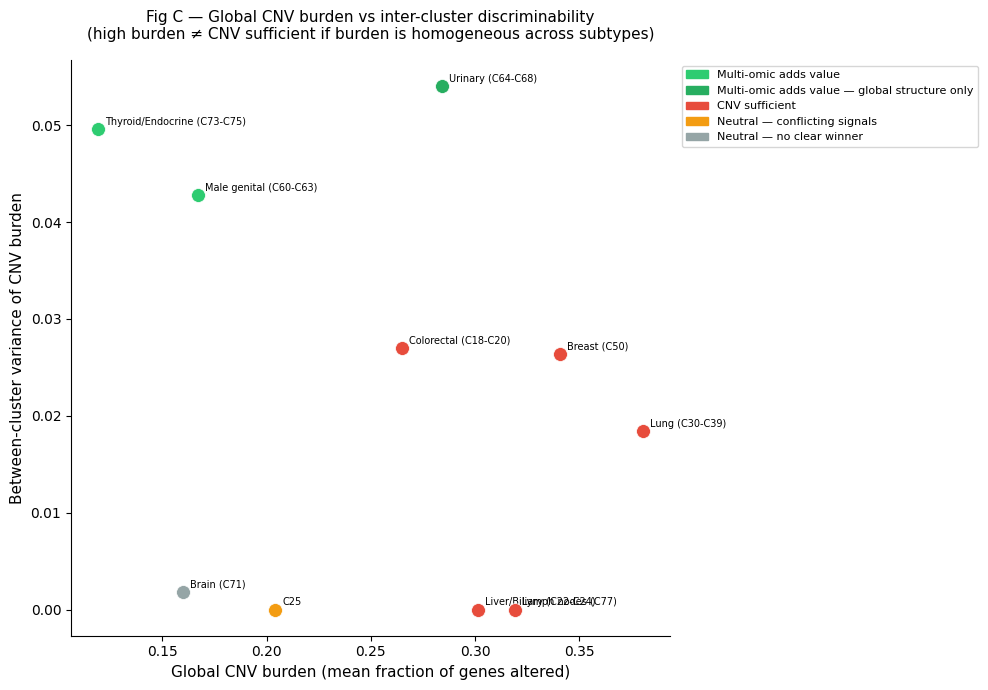

In [17]:
#  Global burden vs between-cluster variance 
# - x axis : global CNV burden (how much CNV overall)
# - y axis : between-cluster variance of burden (how discriminant)
# - Esophagus should appear: high x, low y → confirms the insight

fig, ax = plt.subplots(figsize=(10, 7))

for _, row in df_burden_var.iterrows():
    color = INTERP_COLORS.get(row["interpretation"], "#cccccc")
    ax.scatter(
        row["global_burden"],
        row["between_cluster_var"],
        color=color, s=100, zorder=3, edgecolors="white", linewidths=0.5,
    )
    ax.annotate(
        row["cancer_group"],
        (row["global_burden"], row["between_cluster_var"]),
        fontsize=7, xytext=(5, 3), textcoords="offset points",
    )

patches = [
    mpatches.Patch(color=v, label=k)
    for k, v in INTERP_COLORS.items() if k in KEEP
]
ax.legend(handles=patches, bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
ax.set_xlabel("Global CNV burden (mean fraction of genes altered)", fontsize=11)
ax.set_ylabel("Between-cluster variance of CNV burden", fontsize=11)
ax.set_title(
    "Fig C — Global CNV burden vs inter-cluster discriminability\n"
    "(high burden ≠ CNV sufficient if burden is homogeneous across subtypes)",
    fontsize=11, pad=15,
)
sns.despine()
plt.tight_layout()
plt.savefig(OUT_FIG / "fig_C_burden_vs_intercluster_variance.png", dpi=150, bbox_inches="tight")
plt.show()

### CNV Sufficient — Markers
For each CNV sufficient group:
 - multi-cluster groups  → differential markers between clusters
 - single-cluster groups → top most frequent alterations globally

In [18]:
# Merge CNV data with Leiden CNV clusters 
cnv_leiden_merged = {}

for grp, df_cl in leiden_cnv.items():
    df_grp = df_meta[df_meta["cancer_group"] == grp][
        ["biosample_id", "cancer_group"] + alt_cols
    ].merge(df_cl[["biosample_id", "cluster"]], on="biosample_id", how="inner")

    n_clusters = df_grp["cluster"].nunique()
    cnv_leiden_merged[grp] = df_grp
    print(f"  {grp:40s}  n={len(df_grp):4d}  clusters={n_clusters}")

  Lung (C30-C39)                            n=1182  clusters=6
  Liver/Biliary (C22-C24)                   n= 397  clusters=1
  Colorectal (C18-C20)                      n= 550  clusters=2
  Lymph nodes (C77)                         n= 236  clusters=1
  Breast (C50)                              n= 963  clusters=6
  Head & Neck (C00-C14)                     n=   0  clusters=0
  C25                                       n= 165  clusters=1


In [19]:
# Classify groups by number of clusters ───────────────
multi_cluster_groups  = [
    grp for grp, df in cnv_leiden_merged.items()
    if df["cluster"].nunique() >= 2
]
single_cluster_groups = [
    grp for grp, df in cnv_leiden_merged.items()
    if df["cluster"].nunique() < 2
]

print("Multi-cluster groups  :", multi_cluster_groups)
print("Single-cluster groups :", single_cluster_groups)

Multi-cluster groups  : ['Lung (C30-C39)', 'Colorectal (C18-C20)', 'Breast (C50)']
Single-cluster groups : ['Liver/Biliary (C22-C24)', 'Lymph nodes (C77)', 'Head & Neck (C00-C14)', 'C25']


In [20]:
# Differential markers — multi-cluster groups 
cnv_diff_markers = {}

for grp in multi_cluster_groups:
    df_grp  = cnv_leiden_merged[grp]
    markers = top_differential_markers(df_grp, alt_cols, cluster_col="cluster", top_n=20)
    cnv_diff_markers[grp] = markers

    print(f"\n{'='*65}")
    print(f"GROUP: {grp}  ({df_grp['cluster'].nunique()} clusters, n={len(df_grp)})")
    print(f"{'='*65}")

    # Show top markers PER CLUSTER separately
    for cl in sorted(df_grp["cluster"].unique()):
        n_cl = (df_grp["cluster"] == cl).sum()
        top_cl = (
            markers[markers["cluster"] == cl]
            .sort_values("delta", key=abs, ascending=False)
            .head(10)
        )
        print(f"\n  ── Cluster {cl} (n={n_cl}) ──")
        print(top_cl[["gene_label", "freq_cluster", "freq_rest", "delta"]].to_string(index=False))


GROUP: Lung (C30-C39)  (6 clusters, n=1182)

  ── Cluster 0 (n=311) ──
gene_label  freq_cluster  freq_rest  delta
  MSH3 del         0.064      0.634 -0.569
 AGGF1 del         0.064      0.629 -0.565
  MITF del         0.158      0.720 -0.562
 FOXP1 del         0.167      0.728 -0.561
 RASA1 del         0.071      0.630 -0.560
  RYBP del         0.161      0.718 -0.557
 ATXN7 del         0.174      0.730 -0.557
  SHQ1 del         0.161      0.715 -0.554
PIK3R1 del         0.061      0.615 -0.554
 MEF2C del         0.074      0.628 -0.554

  ── Cluster 1 (n=259) ──
gene_label  freq_cluster  freq_rest  delta
  PHF1 dup         0.579      0.059  0.521
  H3C1 dup         0.587      0.067  0.520
  H3C2 dup         0.587      0.067  0.520
  H3C3 dup         0.587      0.067  0.520
   HFE dup         0.587      0.067  0.520
  H1-2 dup         0.587      0.067  0.520
H2BC11 dup         0.583      0.065  0.518
  MDC1 dup         0.595      0.078  0.517
 H3C10 dup         0.579      0.063  0.51

In [21]:
# Global markers — single-cluster groups 
cnv_global_markers = {}

for grp in single_cluster_groups:
    df_grp  = cnv_leiden_merged[grp]
    markers = top_global_markers(df_grp, alt_cols, top_n=20)
    cnv_global_markers[grp] = markers

    print(f"\n{'='*65}")
    print(f"GROUP: {grp}  (1 cluster, n={len(df_grp)})")
    print(f"{'='*65}")
    print(markers[["gene_label", "frequency"]].to_string(index=False))


GROUP: Liver/Biliary (C22-C24)  (1 cluster, n=397)
gene_label  frequency
 CKS1B dup   0.700252
  DDR2 dup   0.700252
  MUC1 dup   0.697733
  NUF2 dup   0.697733
  RIT1 dup   0.690176
  PBX1 dup   0.690176
  PRCC dup   0.687657
  ADAR dup   0.687657
 NTRK1 dup   0.687657
 MEF2D dup   0.687657
YY1AP1 dup   0.685139
  LMNA dup   0.685139
  SDHC dup   0.685139
 PRRX1 dup   0.685139
FCGR2B dup   0.682620
  AIM2 dup   0.680101
 FCRL4 dup   0.680101
  TPM3 dup   0.680101
 NCSTN dup   0.680101
  COP1 dup   0.680101

GROUP: Lymph nodes (C77)  (1 cluster, n=236)
  gene_label  frequency
  CDKN2A del   0.665254
  CDKN2B del   0.661017
    MTAP del   0.652542
   PTPRD del   0.584746
   MLLT3 del   0.563559
    NFIB del   0.559322
 CREB3L2 dup   0.550847
    BRAF dup   0.550847
     AGK dup   0.546610
   PSIP1 del   0.546610
KIAA1549 dup   0.546610
   KDM4C del   0.542373
  TRIM24 dup   0.542373
    MGAM dup   0.542373
   PRSS1 dup   0.533898
 SMARCA2 del   0.533898
     SMO dup   0.529661
    SND1

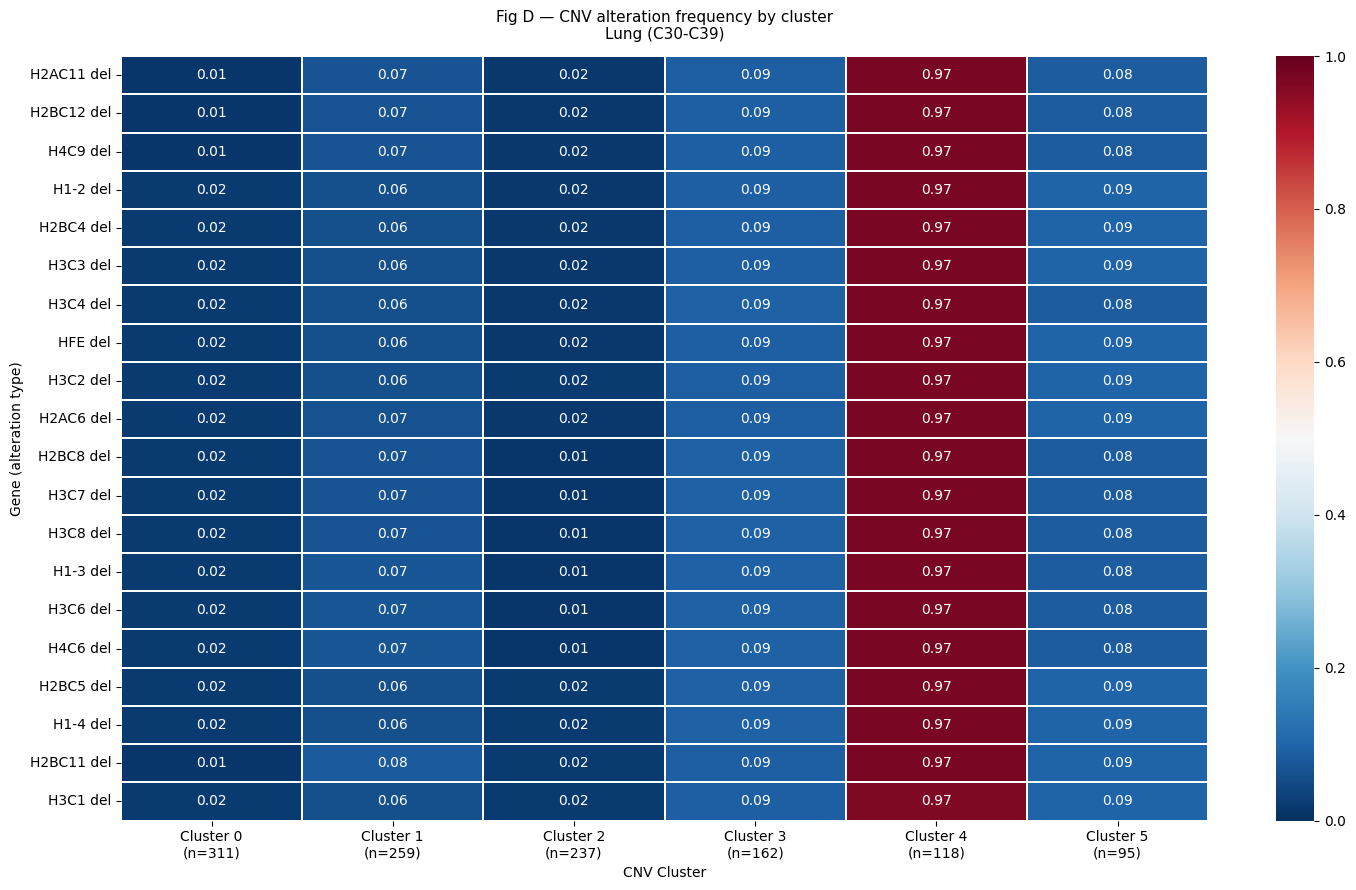

Saved: Lung (C30-C39)


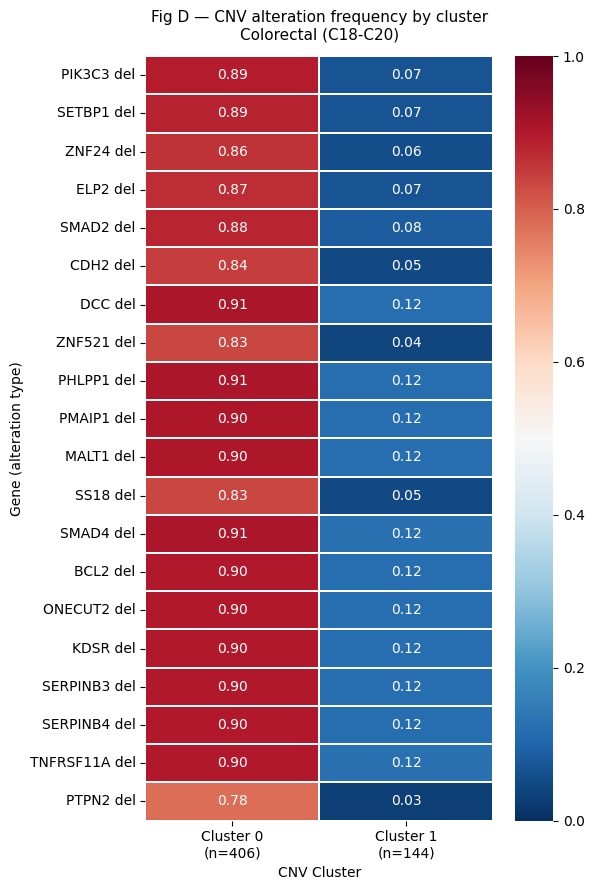

Saved: Colorectal (C18-C20)


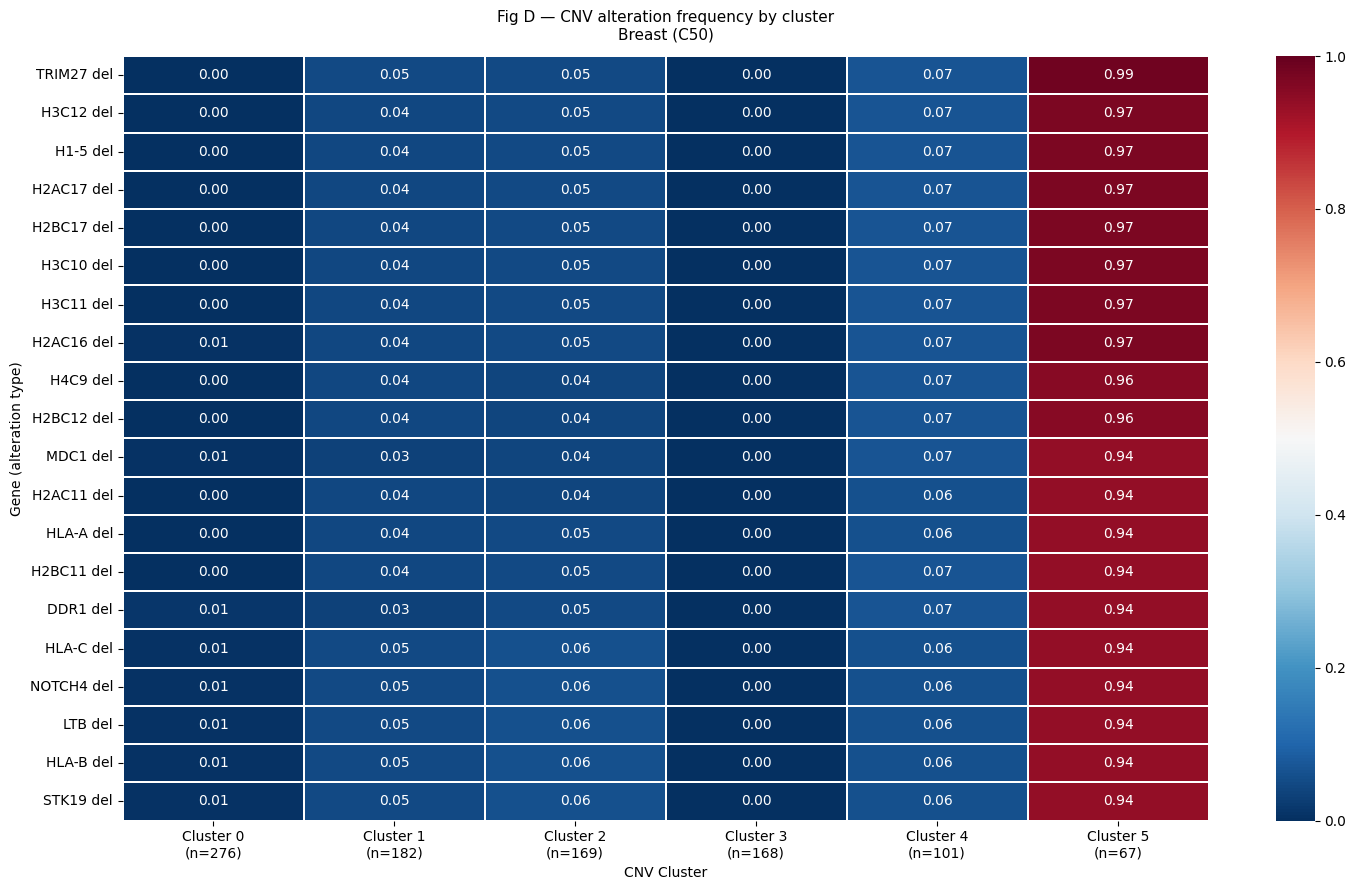

Saved: Breast (C50)


In [22]:
# Fig D — Heatmaps for multi-cluster groups 
for grp in multi_cluster_groups:
    df_grp   = cnv_leiden_merged[grp]
    markers  = cnv_diff_markers[grp]

    # Top 20 most differential features across all clusters
    top_features = (
        markers
        .sort_values("delta", key=abs, ascending=False)
        .drop_duplicates("feature")
        .head(20)["feature"]
        .tolist()
    )

    freq_mat = compute_freq_matrix(df_grp, top_features, cluster_col="cluster")
    freq_mat.index = [
        f.replace("cnv_", "").replace("__dup", " dup").replace("__del", " del")
        for f in freq_mat.index
    ]

    # Cluster sizes for column annotations
    cluster_sizes = df_grp["cluster"].value_counts().sort_index()
    col_labels = {
        cl: f"Cluster {cl}\n(n={cluster_sizes[cl]})"
        for cl in freq_mat.columns
    }
    freq_mat.columns = [col_labels[c] for c in freq_mat.columns]

    fig, ax = plt.subplots(figsize=(max(6, freq_mat.shape[1] * 2.5), max(8, 20 * 0.45)))
    sns.heatmap(
        freq_mat,
        cmap="RdBu_r", center=0.5, vmin=0, vmax=1,
        annot=True, fmt=".2f", linewidths=0.3,
        ax=ax,
    )
    ax.set_title(
        f"Fig D — CNV alteration frequency by cluster\n{grp}",
        fontsize=11, pad=12,
    )
    ax.set_xlabel("CNV Cluster")
    ax.set_ylabel("Gene (alteration type)")
    plt.tight_layout()
    plt.savefig(OUT_FIG / f"fig_D_heatmap_cnv_{safe_name(grp)}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {grp}")

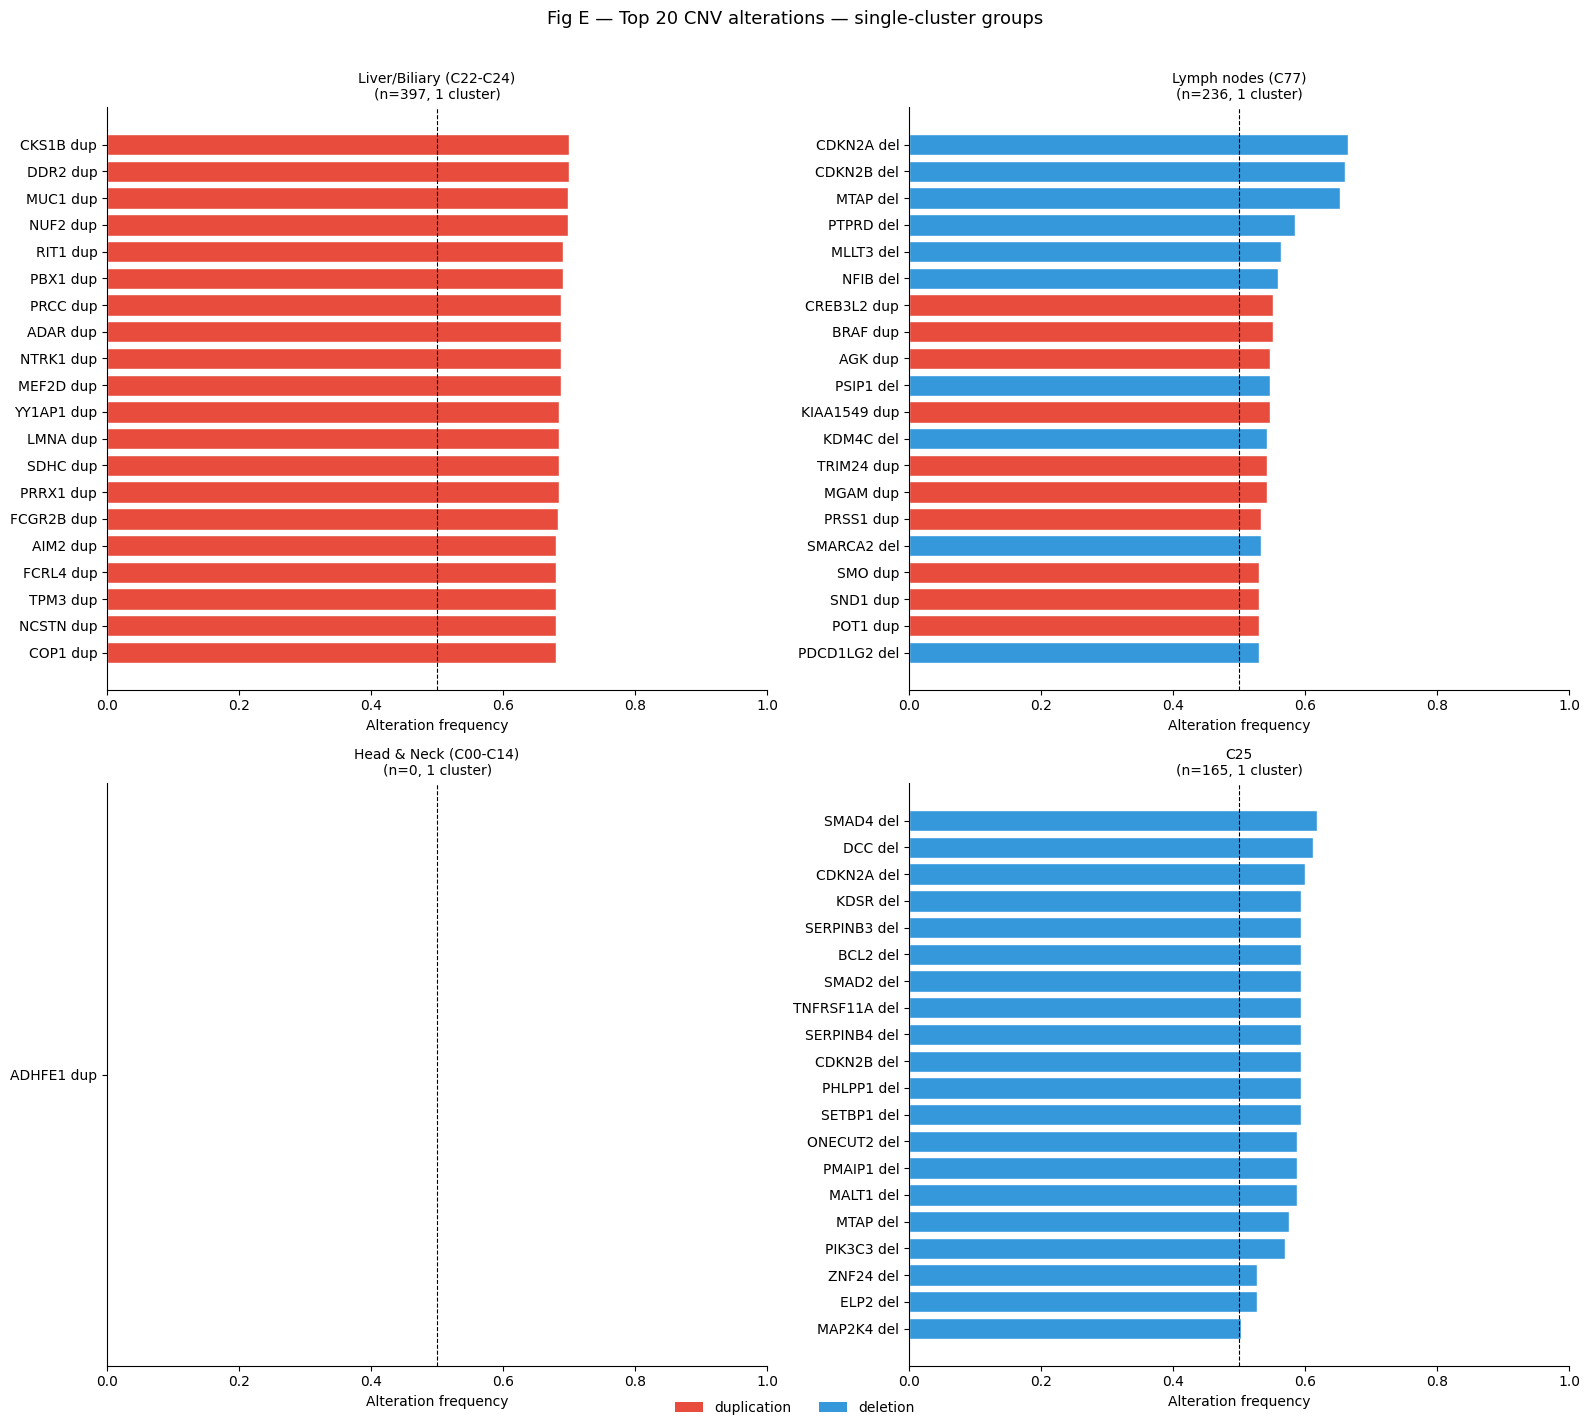

Saved: Fig E


In [23]:
# Fig E — Barplots for single-cluster groups 
n_groups = len(single_cluster_groups)
ncols    = 2
nrows    = (n_groups + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 7))
axes = axes.flatten()

for idx, grp in enumerate(single_cluster_groups):
    df_grp  = cnv_leiden_merged[grp]
    markers = cnv_global_markers[grp]

    gene_labels = markers["gene_label"].tolist()
    frequencies = markers["frequency"].tolist()
    colors      = ["#e74c3c" if "dup" in g else "#3498db" for g in gene_labels]

    ax = axes[idx]
    ax.barh(gene_labels[::-1], frequencies[::-1], color=colors[::-1], edgecolor="white")
    ax.axvline(0.5, color="black", linestyle="--", linewidth=0.8)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Alteration frequency")
    ax.set_title(
        f"{grp}\n(n={len(df_grp)}, 1 cluster)",
        fontsize=10,
    )
    sns.despine(ax=ax)

# Hide unused axes if odd number of groups
for idx in range(len(single_cluster_groups), len(axes)):
    axes[idx].set_visible(False)

legend_elements = [
    mpatches.Patch(facecolor="#e74c3c", label="duplication"),
    mpatches.Patch(facecolor="#3498db", label="deletion"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2, fontsize=10, frameon=False)
plt.suptitle(
    "Fig E — Top 20 CNV alterations — single-cluster groups",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.savefig(OUT_FIG / "fig_E_barplot_cnv_single_cluster.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: Fig E")

### Multi-omics Adds Value — CNV Alone Does Not Separate Subtypes

In [24]:
# Merge CNV data with Leiden MOFA clusters 
mofa_leiden_merged = {}

for grp, df_cl in leiden_mofa.items():
    df_grp = df_meta[df_meta["cancer_group"] == grp][
        ["biosample_id", "cancer_group", "cnv_burden"] + alt_cols
    ].merge(df_cl[["biosample_id", "cluster"]], on="biosample_id", how="inner")

    mofa_leiden_merged[grp] = df_grp
    print(f"  {grp:40s}  n={len(df_grp):4d}  clusters={sorted(df_grp['cluster'].unique())}")

  Brain (C71)                               n= 737  clusters=[np.int64(0), np.int64(1)]
  Male genital (C60-C63)                    n= 617  clusters=[np.int64(0), np.int64(1)]
  Thyroid/Endocrine (C73-C75)               n= 718  clusters=[np.int64(0), np.int64(1)]
  Urinary (C64-C68)                         n=1109  clusters=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


In [25]:
# CNV burden per cluster — MOFA groups 
# Key question: is CNV burden homogeneous across MOFA clusters?
# If yes → CNV cannot discriminate → multi-omics needed.

print("CNV burden per cluster (MOFA groups)")
print("=" * 65)

burden_cluster_records = []

for grp, df_grp in mofa_leiden_merged.items():
    cluster_stats = (
        df_grp.groupby("cluster")["cnv_burden"]
        .agg(mean="mean", std="std", n="count")
        .reset_index()
    )
    cluster_stats["cancer_group"] = grp
    burden_cluster_records.append(cluster_stats)

    between_var = cluster_stats["mean"].var()
    print(f"\n{grp}  (between-cluster variance = {between_var:.6f})")
    print(cluster_stats[["cluster", "mean", "std", "n"]].to_string(index=False))

df_burden_clusters = pd.concat(burden_cluster_records, ignore_index=True)

CNV burden per cluster (MOFA groups)

Brain (C71)  (between-cluster variance = 0.001799)
 cluster     mean      std   n
       0 0.173669 0.150684 566
       1 0.113682 0.050024 171

Male genital (C60-C63)  (between-cluster variance = 0.042805)
 cluster     mean      std   n
       0 0.106047 0.119397 488
       1 0.398638 0.132600 129

Thyroid/Endocrine (C73-C75)  (between-cluster variance = 0.049620)
 cluster     mean      std   n
       0 0.021353 0.075790 495
       1 0.336378 0.294183 223

Urinary (C64-C68)  (between-cluster variance = 0.054002)
 cluster     mean      std   n
       0 0.114745 0.112588 276
       1 0.279858 0.173162 262
       2 0.280593 0.173377 135
       3 0.183471 0.176532 105
       4 0.492018 0.159107  95
       5 0.169512 0.074466  86
       6 0.412444 0.188998  78
       7 0.828273 0.195732  72


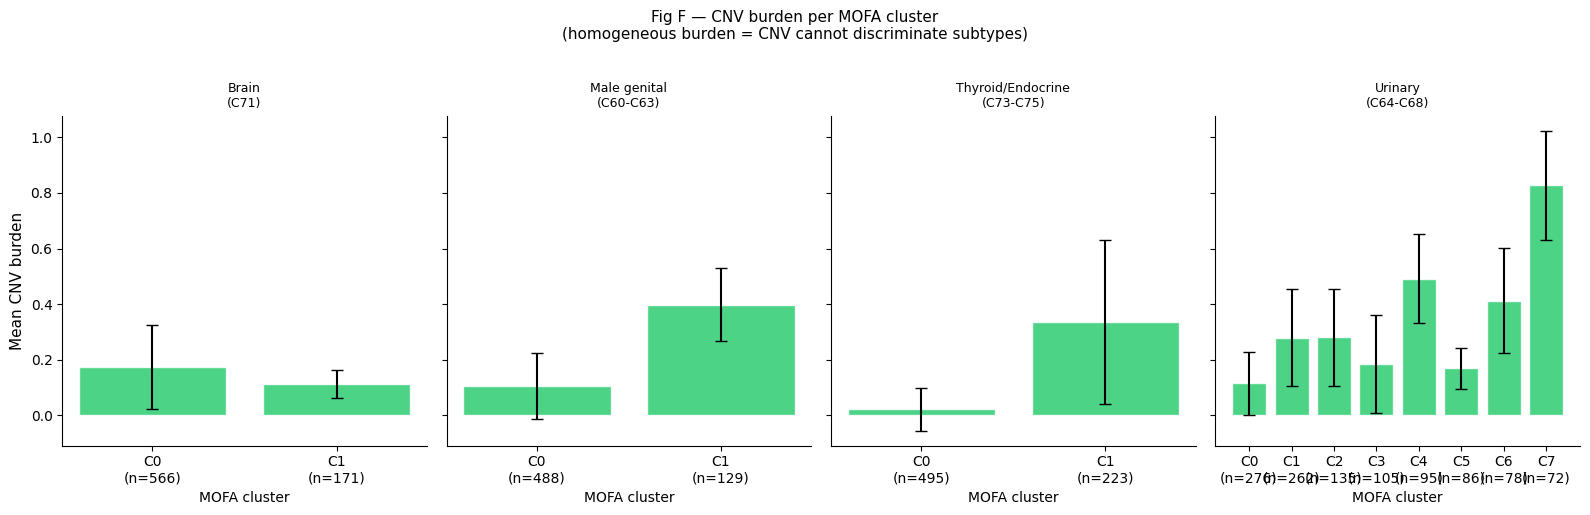

In [26]:
# Fig F — CNV burden per cluster, MOFA groups 
# Expected: bars within each group are similar heights
# = CNV burden does not vary between MOFA clusters

n_groups = len(mofa_leiden_merged)
fig, axes = plt.subplots(1, n_groups, figsize=(4 * n_groups, 5), sharey=True)

for ax, (grp, df_grp) in zip(axes, mofa_leiden_merged.items()):
    cluster_means = df_grp.groupby("cluster")["cnv_burden"].mean()
    cluster_stds  = df_grp.groupby("cluster")["cnv_burden"].std()
    cluster_ns    = df_grp.groupby("cluster")["cnv_burden"].count()

    ax.bar(
        [f"C{c}\n(n={cluster_ns[c]})" for c in cluster_means.index],
        cluster_means.values,
        yerr=cluster_stds.values,
        color=INTERP_COLORS["Multi-omic adds value"],
        edgecolor="white",
        capsize=4,
        alpha=0.85,
    )
    ax.set_title(grp.replace(" (", "\n("), fontsize=9)
    ax.set_xlabel("MOFA cluster")
    sns.despine(ax=ax)

axes[0].set_ylabel("Mean CNV burden", fontsize=11)
plt.suptitle(
    "Fig F — CNV burden per MOFA cluster\n"
    "(homogeneous burden = CNV cannot discriminate subtypes)",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.savefig(OUT_FIG / "fig_F_cnv_burden_per_mofa_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

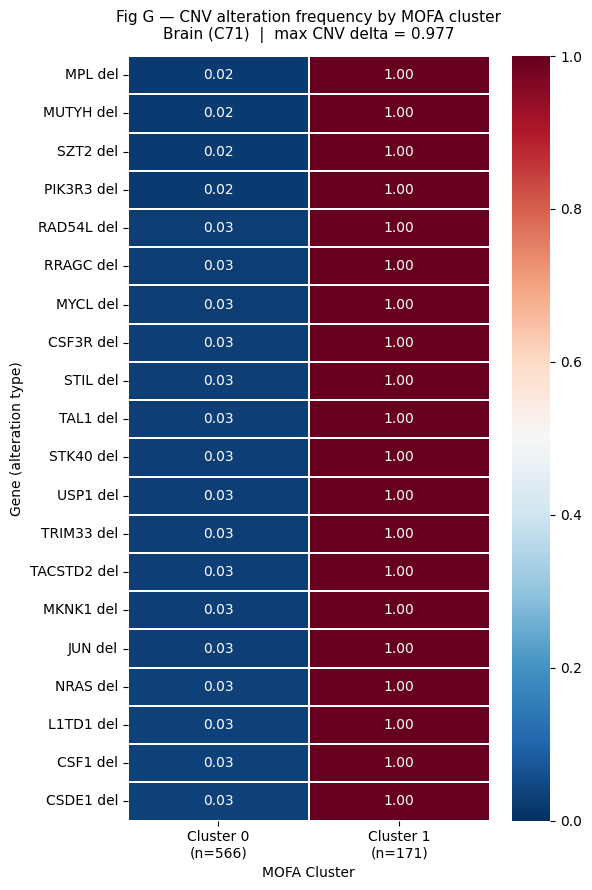

Saved: Brain (C71)  (max delta = 0.977)


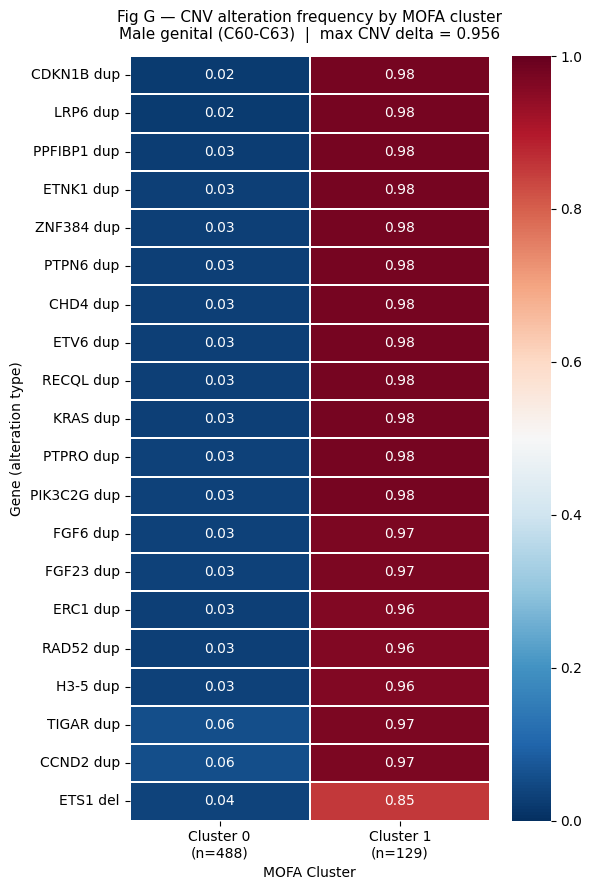

Saved: Male genital (C60-C63)  (max delta = 0.956)


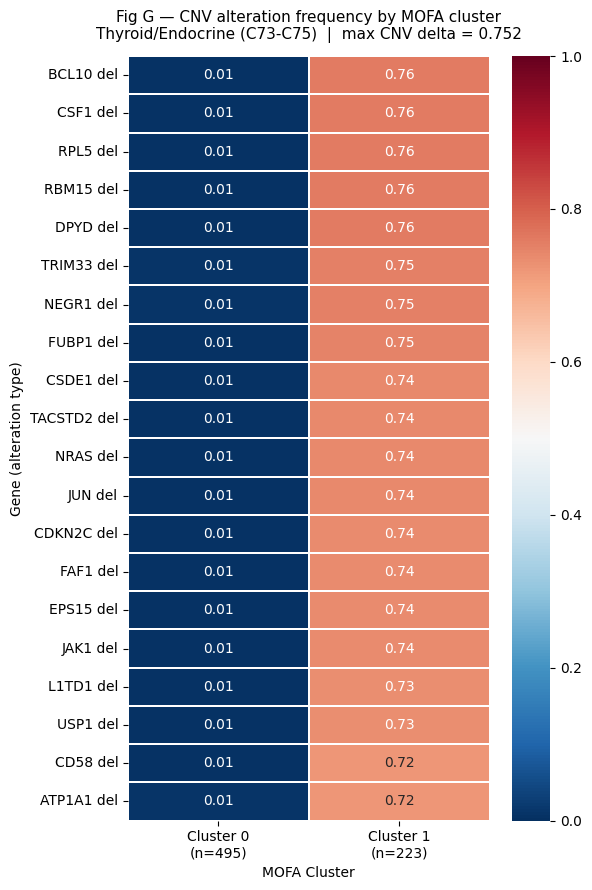

Saved: Thyroid/Endocrine (C73-C75)  (max delta = 0.752)


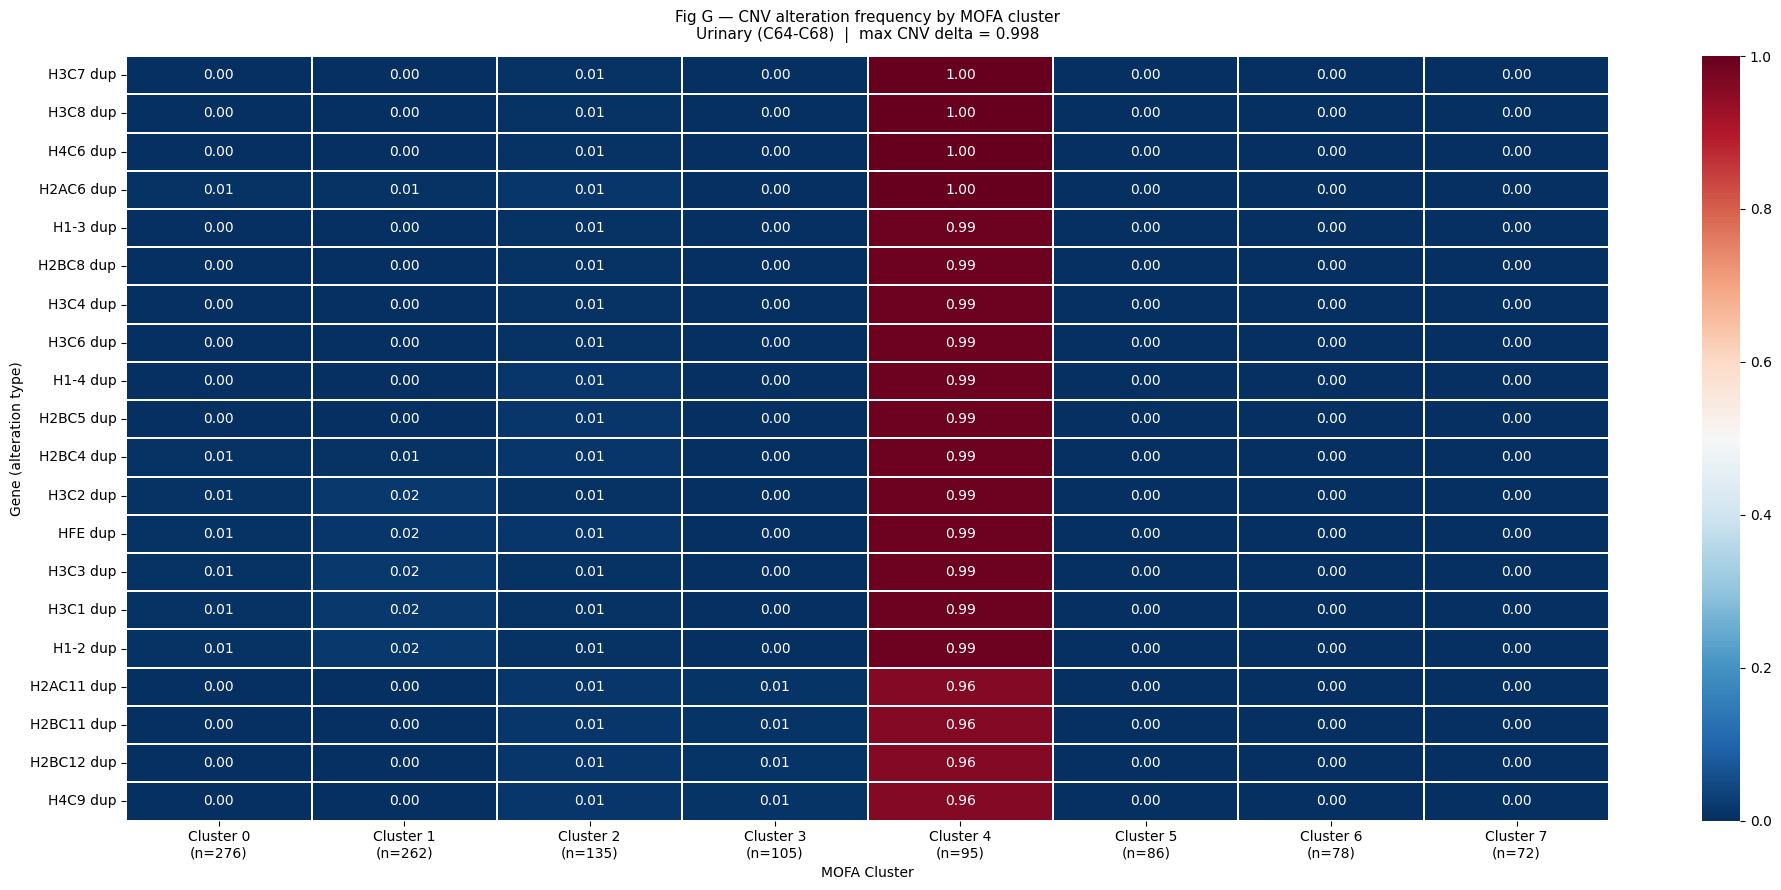

Saved: Urinary (C64-C68)  (max delta = 0.998)


In [27]:
# CNV alteration frequency heatmaps, MOFA groups
# Expected: no strong differential CNV pattern between clusters
# (contrast with Fig D where CNV sufficient groups show clear patterns)

for grp, df_grp in mofa_leiden_merged.items():
    if df_grp["cluster"].nunique() < 2:
        print(f"Skipping {grp} — only 1 cluster")
        continue

    markers = top_differential_markers(df_grp, alt_cols, cluster_col="cluster", top_n=20)
    top_features = (
        markers
        .sort_values("delta", key=abs, ascending=False)
        .drop_duplicates("feature")
        .head(20)["feature"]
        .tolist()
    )

    # Max delta — key metric: how different are CNV profiles between clusters?
    max_delta = markers["delta"].abs().max()

    freq_mat = compute_freq_matrix(df_grp, top_features, cluster_col="cluster")
    freq_mat.index = [
        f.replace("cnv_", "").replace("__dup", " dup").replace("__del", " del")
        for f in freq_mat.index
    ]

    cluster_sizes = df_grp["cluster"].value_counts().sort_index()
    freq_mat.columns = [
        f"Cluster {c}\n(n={cluster_sizes[c]})" for c in freq_mat.columns
    ]

    fig, ax = plt.subplots(figsize=(max(6, freq_mat.shape[1] * 2.5), max(8, 20 * 0.45)))
    sns.heatmap(
        freq_mat,
        cmap="RdBu_r", center=0.5, vmin=0, vmax=1,
        annot=True, fmt=".2f", linewidths=0.3,
        ax=ax,
    )
    ax.set_title(
        f"Fig G — CNV alteration frequency by MOFA cluster\n"
        f"{grp}  |  max CNV delta = {max_delta:.3f}",
        fontsize=11, pad=12,
    )
    ax.set_xlabel("MOFA Cluster")
    ax.set_ylabel("Gene (alteration type)")
    plt.tight_layout()
    plt.savefig(OUT_FIG / f"fig_G_heatmap_cnv_mofa_{safe_name(grp)}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {grp}  (max delta = {max_delta:.3f})")

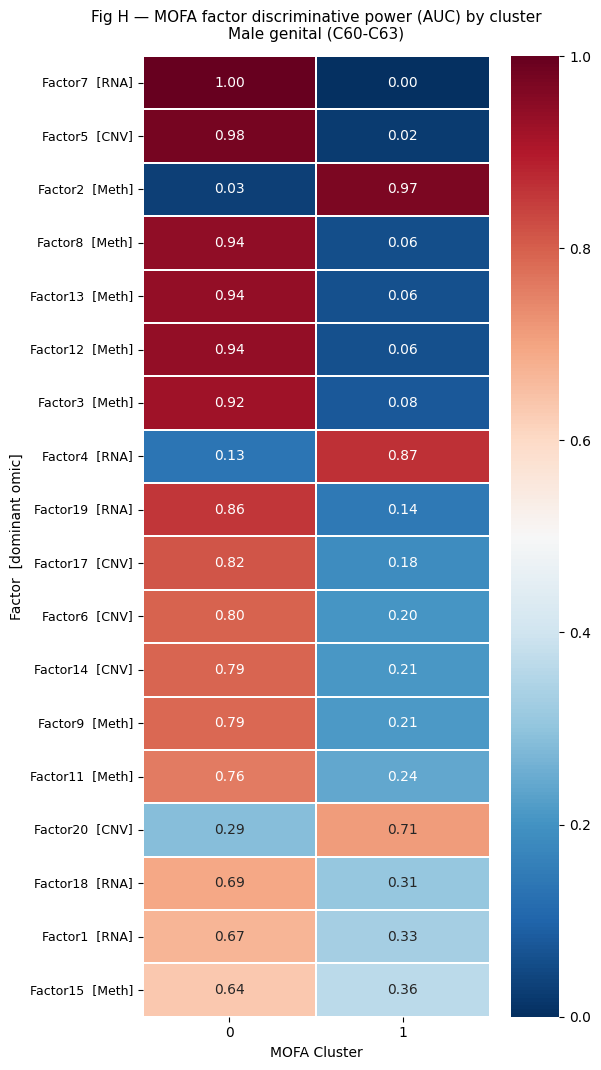

Saved: Male genital (C60-C63)


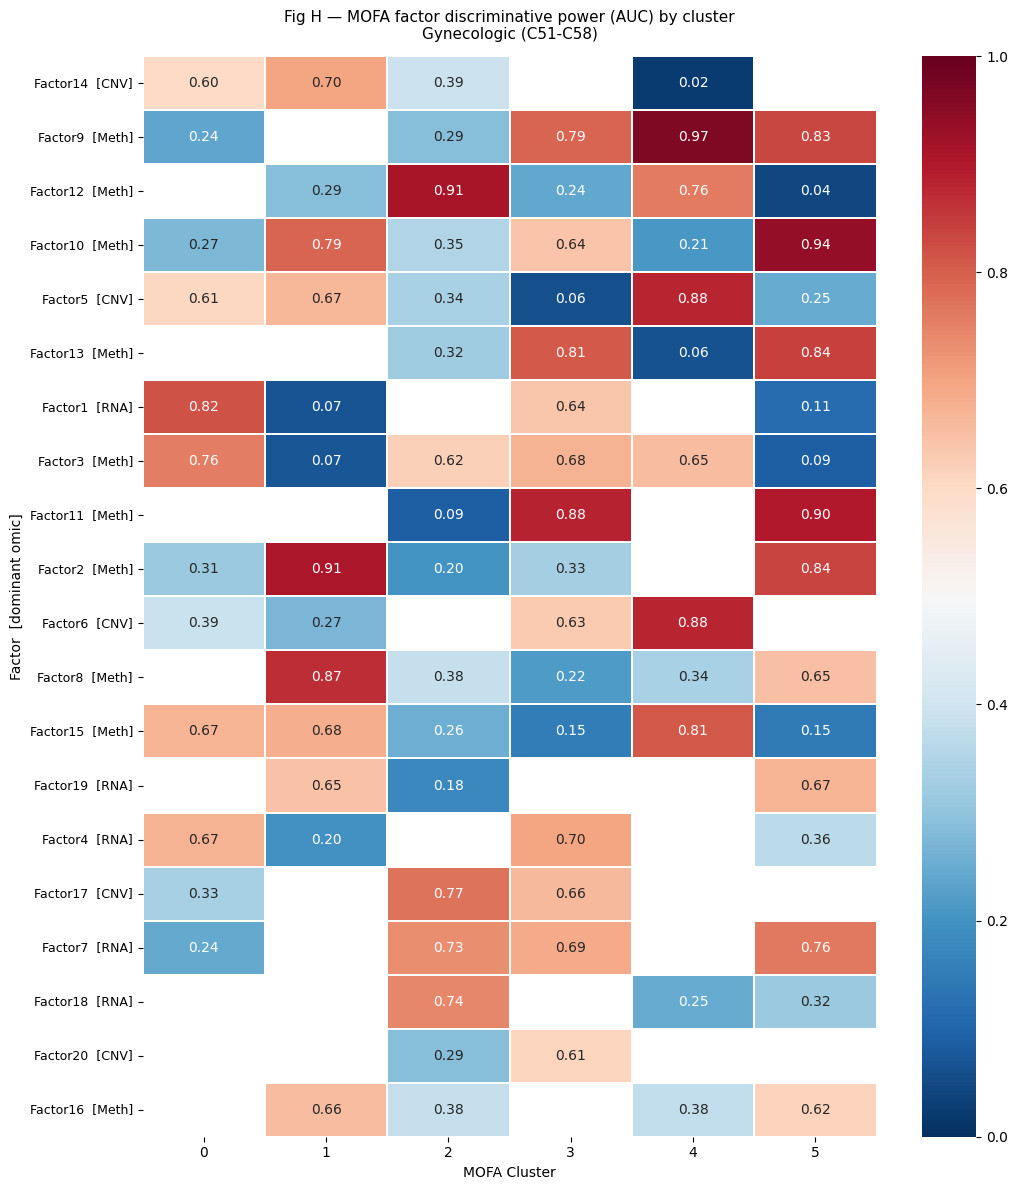

Saved: Gynecologic (C51-C58)


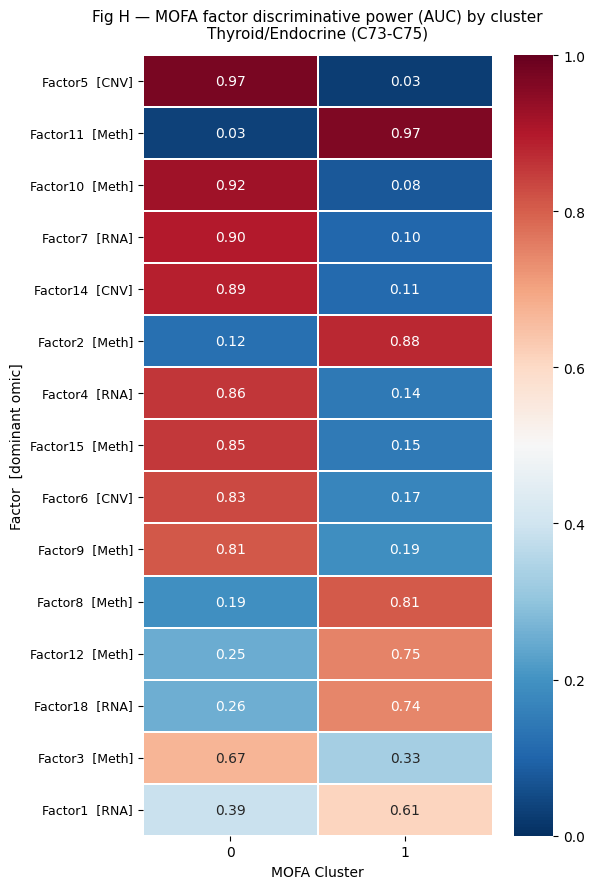

Saved: Thyroid/Endocrine (C73-C75)


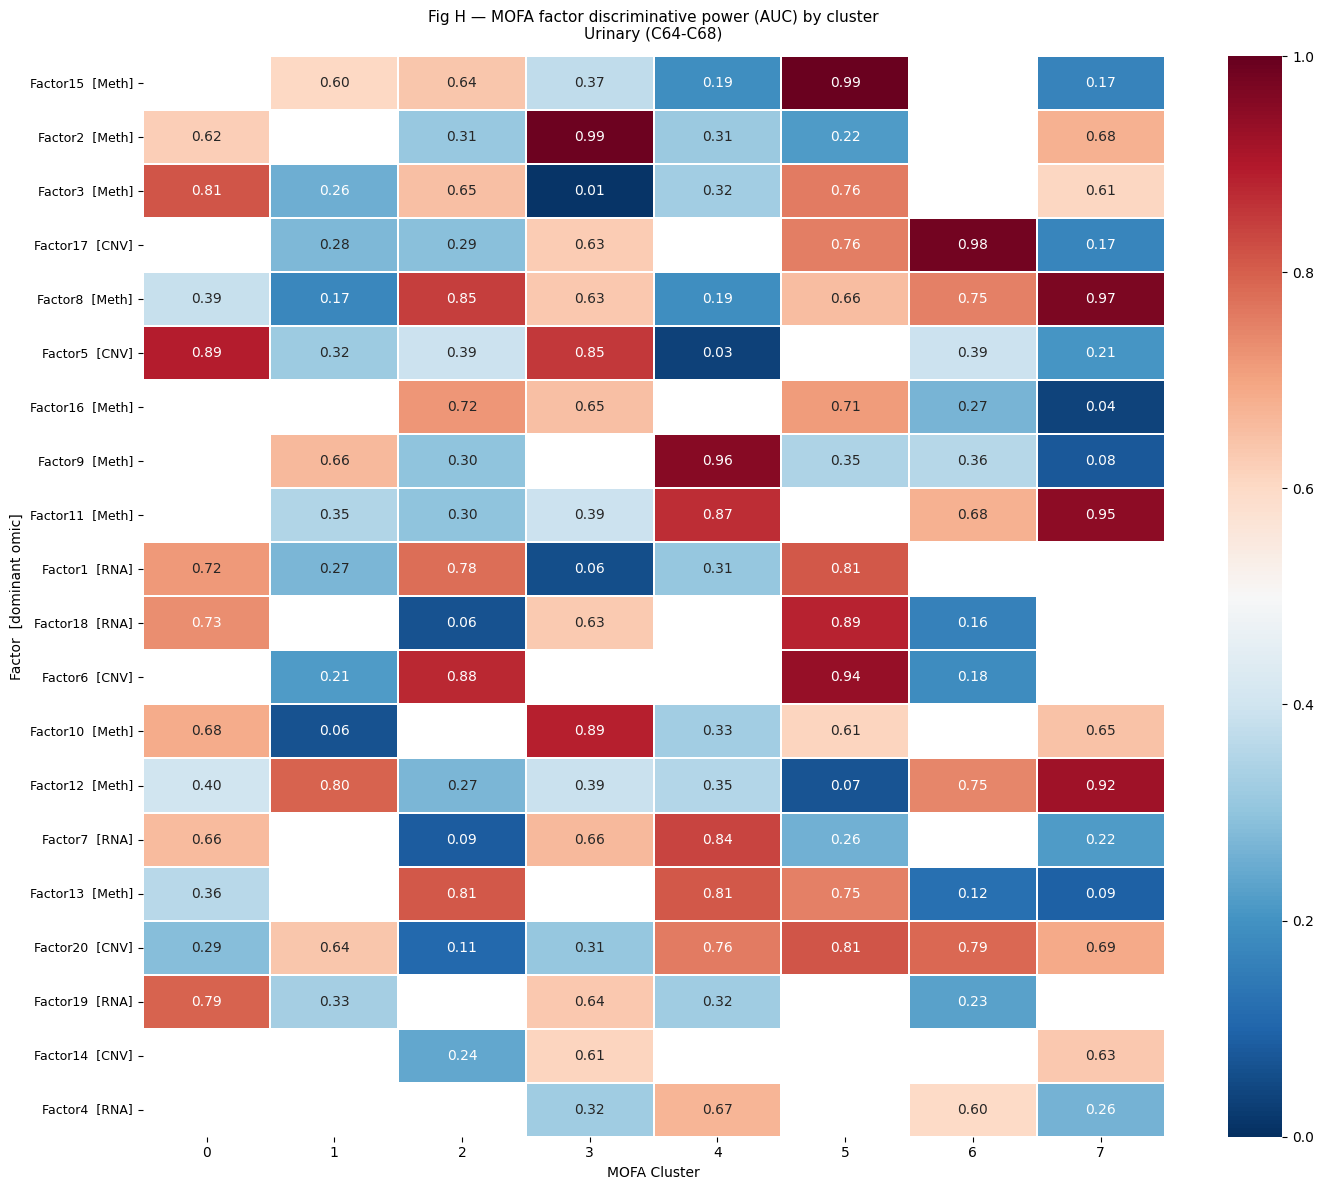

Saved: Urinary (C64-C68)


In [28]:
# Fig H — MOFA factor AUC heatmap per group ────────────
# Shows which factor discriminates which cluster, and which omic
# dominates that factor → the omic that CNV missed

MOFA_VALUE_GROUPS = df_comp[
    df_comp["interpretation"].str.startswith("Multi-omic")
]["cancer_group"].tolist()

for grp in MOFA_VALUE_GROUPS:
    sigs = df_mofa_sig[df_mofa_sig["cancer_group"] == grp].copy()
    if sigs.empty:
        print(f"No significant factors for {grp}")
        continue

    # Pivot: rows = factor, cols = cluster, values = AUC
    pivot = sigs.pivot_table(index="factor", columns="cluster", values="auc")

    # Sort by discriminative power
    pivot["_max_disc"] = (pivot - 0.5).abs().max(axis=1)
    pivot = pivot.sort_values("_max_disc", ascending=False).drop(columns="_max_disc")

    # Annotate y-axis with dominant omic
    factor_omic  = sigs.groupby("factor")["dominant_omic"].first()
    omic_colors  = {"CNV": "#3498db", "Meth": "#e74c3c", "RNA": "#2ecc71"}
    ytick_labels = [
        f"{f}  [{factor_omic.get(f, '?')}]"
        for f in pivot.index
    ]

    fig, ax = plt.subplots(figsize=(max(6, pivot.shape[1] * 1.8), max(5, len(pivot) * 0.6)))
    sns.heatmap(
        pivot,
        cmap="RdBu_r", center=0.5, vmin=0, vmax=1,
        annot=True, fmt=".2f", linewidths=0.3,
        ax=ax,
    )
    ax.set_yticklabels(ytick_labels, fontsize=9)
    ax.set_title(
        f"Fig H — MOFA factor discriminative power (AUC) by cluster\n{grp}",
        fontsize=11, pad=12,
    )
    ax.set_xlabel("MOFA Cluster")
    ax.set_ylabel("Factor  [dominant omic]")
    plt.tight_layout()
    plt.savefig(OUT_FIG / f"fig_H_mofa_auc_{safe_name(grp)}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {grp}")

In [29]:
#  Top marker genes per discriminant factor ─────────────
# For each significant factor × cluster, show top features
# by absolute MOFA loading — the actual genes driving the signal

print("TOP MARKER GENES PER DISCRIMINANT FACTOR")

marker_records = []

for grp in MOFA_VALUE_GROUPS:
    sigs = df_mofa_sig[df_mofa_sig["cancer_group"] == grp].copy()
    if sigs.empty:
        continue

    sigs = sigs.sort_values("disc_power", ascending=False)

    print(f"GROUP: {grp}")
    print(f"{'='*70}")

    for _, row in sigs.iterrows():
        factor    = row["factor"]
        omic      = row["dominant_omic"]
        cluster   = row["cluster"]
        auc       = row["auc"]
        direction = "↑" if row["auc"] > 0.5 else "↓"

        df_W = W_map.get(omic)
        if df_W is None or factor not in df_W.columns:
            continue

        top_genes = get_top_loadings(df_W, factor, top_n=10)
        top_genes["cancer_group"] = grp
        top_genes["cluster"]      = cluster
        top_genes["factor"]       = factor
        top_genes["omic"]         = omic
        top_genes["auc"]          = auc
        marker_records.append(top_genes)

        print(f"\n  Cluster {cluster} | {factor} | {omic} | AUC={auc:.3f} {direction}")
        for _, g in top_genes.iterrows():
            sign = "+" if g["loading"] > 0 else "-"
            print(f"    {sign} {g['feature']:40s}  |W|={g['abs_loading']:.4f}")

df_markers_all = pd.concat(marker_records, ignore_index=True)
print(f"\nTotal marker records stored: {len(df_markers_all)}")

TOP MARKER GENES PER DISCRIMINANT FACTOR
GROUP: Male genital (C60-C63)

  Cluster 1 | Factor7 | RNA | AUC=0.001 ↓
    + ISX_RNA                                   |W|=0.3084
    - PRDM14_RNA                                |W|=0.2401
    + A1CF_RNA                                  |W|=0.1787
    - SSX1_RNA                                  |W|=0.1742
    - PAX3_RNA                                  |W|=0.1642
    - DDX4_RNA                                  |W|=0.1584
    - FOXR1_RNA                                 |W|=0.1446
    - EZHIP_RNA                                 |W|=0.1423
    - TLX3_RNA                                  |W|=0.1393
    - CNBD1_RNA                                 |W|=0.1292

  Cluster 0 | Factor7 | RNA | AUC=0.999 ↑
    + ISX_RNA                                   |W|=0.3084
    - PRDM14_RNA                                |W|=0.2401
    + A1CF_RNA                                  |W|=0.1787
    - SSX1_RNA                                  |W|=0.1742
    - PAX3_RNA   

### Summary

In [30]:
# Build the summary table 

summary_records = []

# CNV sufficient groups 
cnv_sufficient_data = {
    "Lung (C30-C39)": {
        "n_clusters_cnv": 3, "n_clusters_mofa": None,
        "dominant_omic": "CNV",
        "max_cnv_delta": 0.631,
        "biological_note": "3p14-21 deletion (FHIT, BAP1, PBRM1, ROBO1/2) defines cluster 0 (SCLC-like). Clusters 1-2 = NSCLC subtypes. Strong chromosomal signal.",
    },
    "Colorectal (C18-C20)": {
        "n_clusters_cnv": 2, "n_clusters_mofa": None,
        "dominant_omic": "CNV",
        "max_cnv_delta": 0.822,
        "biological_note": "18q deletion (SMAD2, SMAD4, DCC = TGF-β pathway) defines cluster 0 (CIN). Cluster 1 = MSI-like (genomically stable). Highest delta of all groups.",
    },
    "Breast (C50)": {
        "n_clusters_cnv": 2, "n_clusters_mofa": None,
        "dominant_omic": "CNV",
        "max_cnv_delta": 0.429,
        "biological_note": "Cluster 0 = 8q24 amplification (MYC, BAALC). Cluster 1 = 20q13 amplification (ZNF217, GNAS, AURKA). Two distinct amplification landscapes.",
    },
    "Liver/Biliary (C22-C24)": {
        "n_clusters_cnv": 1, "n_clusters_mofa": None,
        "dominant_omic": "CNV",
        "max_cnv_delta": None,
        "biological_note": "Single homogeneous cluster. Dominant 1q gain (CKS1B, DDR2, MUC1). Highly recurrent, no subtype structure needed.",
    },
    "Lymph nodes (C77)": {
        "n_clusters_cnv": 1, "n_clusters_mofa": None,
        "dominant_omic": "CNV",
        "max_cnv_delta": None,
        "biological_note": "Single cluster. Low-grade glioma signature (CDKN2A del + BRAF-KIAA1549 dup). Homogeneous group.",
    },
    "Head & Neck (C00-C14)": {
        "n_clusters_cnv": 1, "n_clusters_mofa": None,
        "dominant_omic": "CNV",
        "max_cnv_delta": None,
        "biological_note": "Reclassified CNV sufficient. 0 significant MOFA factors. 3p14 deletion (FHIT) + 3q amplification (TP63, MAL2). HNSCC canonical signature.",
    },
    "C25": {
        "n_clusters_cnv": 1, "n_clusters_mofa": None,
        "dominant_omic": "CNV",
        "max_cnv_delta": None,
        "biological_note": "Reclassified CNV sufficient. 0 significant MOFA factors. SMAD4 del (~62%), CDKN2A/B del (~60%). PDAC canonical drivers dominate.",
    },
}

# Multi-omic adds value groups 
mofa_value_data = {
    "Brain (C71)": {
        "n_clusters_cnv": None, "n_clusters_mofa": 3,
        "dominant_omic": "Meth",
        "max_cnv_delta": 0.977,
        "between_cluster_var_burden": 0.003031,
    },
    "Male genital (C60-C63)": {
        "n_clusters_cnv": None, "n_clusters_mofa": 2,
        "dominant_omic": "RNA + Meth",
        "max_cnv_delta": 0.956,
        "between_cluster_var_burden": 0.042805,
    },
    "Esophagus/Intestine (C15-C26)": {
        "n_clusters_cnv": None, "n_clusters_mofa": 2,
        "dominant_omic": "Meth",
        "max_cnv_delta": None,
        "between_cluster_var_burden": 0.001405,
    },
    "Thyroid/Endocrine (C73-C75)": {
        "n_clusters_cnv": None, "n_clusters_mofa": 2,
        "dominant_omic": "Meth + CNV",
        "max_cnv_delta": 0.742,
        "between_cluster_var_burden": 0.047305,
    },
    "Urinary (C64-C68)": {
        "n_clusters_cnv": None, "n_clusters_mofa": 8,
        "dominant_omic": "Meth",
        "max_cnv_delta": None,
        "between_cluster_var_burden": 0.055621,    },
}

#  Compute mean CNV burden per group from df_burden 
burden_means = (
    df_burden.groupby("cancer_group")["cnv_burden"]
    .mean()
    .round(3)
)

#  Assemble records 
for grp, info in cnv_sufficient_data.items():
    rec = {
        "cancer_group":             grp,
        "interpretation":           "CNV sufficient" if grp not in CNV_SUFFICIENT_RECLASSIFIED
                                    else "CNV sufficient (reclassified)",
        "mean_cnv_burden":          burden_means.get(grp, None),
        "n_clusters_cnv":           info["n_clusters_cnv"],
        "n_clusters_mofa":          "—",
        "dominant_omic":            info["dominant_omic"],
        "max_cnv_delta":            info["max_cnv_delta"] if info["max_cnv_delta"] else "—",
        "between_cluster_var":      "—",
        "biological_note":          info["biological_note"],
    }
    summary_records.append(rec)

for grp, info in mofa_value_data.items():
    rec = {
        "cancer_group":             grp,
        "interpretation":           "Multi-omic adds value",
        "mean_cnv_burden":          burden_means.get(grp, None),
        "n_clusters_cnv":           "—",
        "n_clusters_mofa":          info["n_clusters_mofa"],
        "dominant_omic":            info["dominant_omic"],
        "max_cnv_delta":            info["max_cnv_delta"] if info["max_cnv_delta"] else "—",
        "between_cluster_var":      round(info["between_cluster_var_burden"], 4),
    }
    summary_records.append(rec)

df_summary = pd.DataFrame(summary_records)

# Sort: CNV sufficient first, then multi-omic, by burden descending
interp_order = {"CNV sufficient": 0, "CNV sufficient (reclassified)": 1, "Multi-omic adds value": 2}
df_summary["_sort"] = df_summary["interpretation"].map(interp_order)
df_summary = df_summary.sort_values(["_sort", "mean_cnv_burden"], ascending=[True, False]).drop(columns="_sort")

print(df_summary.to_string(index=False))

                 cancer_group                interpretation  mean_cnv_burden n_clusters_cnv n_clusters_mofa dominant_omic max_cnv_delta between_cluster_var                                                                                                                                   biological_note
               Lung (C30-C39)                CNV sufficient            0.349              3               —           CNV         0.631                   —            3p14-21 deletion (FHIT, BAP1, PBRM1, ROBO1/2) defines cluster 0 (SCLC-like). Clusters 1-2 = NSCLC subtypes. Strong chromosomal signal.
                 Breast (C50)                CNV sufficient            0.342              2               —           CNV         0.429                   —        Cluster 0 = 8q24 amplification (MYC, BAALC). Cluster 1 = 20q13 amplification (ZNF217, GNAS, AURKA). Two distinct amplification landscapes.
            Lymph nodes (C77)                CNV sufficient            0.320              1   

In [31]:
# Export summary table 
df_summary.to_csv(OUT_DIR / "synthesis_summary_table.tsv", sep="\t", index=False)
print(f"Saved: synthesis_summary_table.tsv")

Saved: synthesis_summary_table.tsv


### NEUTRAL GROUPS

In [32]:
NEUTRAL_GROUPS = {
    "Gynecologic (C51-C58)": "Neutral — conflicting signals",
    "SoftTissue (C49)":      "Neutral — no clear winner",
    "C16":                   "Neutral — no clear winner",
}

In [33]:
# Merge CNV data with Leiden CNV clusters
neutral_leiden_merged = {}

for grp, df_cl in leiden_cnv_neutral.items():
    df_grp = df_meta[df_meta["cancer_group"] == grp][
        ["biosample_id", "cancer_group", "cnv_burden"] + alt_cols
    ].merge(df_cl[["biosample_id", "cluster"]], on="biosample_id", how="inner")

    neutral_leiden_merged[grp] = df_grp
    n_clusters = df_grp["cluster"].nunique()
    print(f"  {grp:40s}  n={len(df_grp):4d}  clusters={sorted(df_grp['cluster'].unique())}")

  Gynecologic (C51-C58)                     n=1135  clusters=[np.int64(0), np.int64(1)]
  SoftTissue (C49)                          n= 196  clusters=[np.int64(0)]
  C16                                       n= 375  clusters=[np.int64(0), np.int64(1)]


In [34]:
# CNV burden per cluster — neutral groups
print("CNV burden per cluster (Neutral groups)")
print("=" * 65)

for grp, df_grp in neutral_leiden_merged.items():
    cluster_stats = (
        df_grp.groupby("cluster")["cnv_burden"]
        .agg(mean="mean", std="std", n="count")
        .reset_index()
    )
    between_var = cluster_stats["mean"].var() if len(cluster_stats) > 1 else 0.0
    interp = NEUTRAL_GROUPS[grp]

    print(f"\n{grp}  [{interp}]  (between-cluster variance = {between_var:.6f})")
    print(cluster_stats[["cluster", "mean", "std", "n"]].to_string(index=False))

CNV burden per cluster (Neutral groups)

Gynecologic (C51-C58)  [Neutral — conflicting signals]  (between-cluster variance = 0.061903)
 cluster     mean      std   n
       0 0.406113 0.184283 792
       1 0.054253 0.070090 343

SoftTissue (C49)  [Neutral — no clear winner]  (between-cluster variance = 0.000000)
 cluster     mean      std   n
       0 0.343319 0.212723 196

C16  [Neutral — no clear winner]  (between-cluster variance = 0.057509)
 cluster     mean      std   n
       0 0.410710 0.161135 237
       1 0.071567 0.065857 138


In [35]:
#  Classify neutral groups by number of clusters 
neutral_multi  = [g for g, df in neutral_leiden_merged.items() if df["cluster"].nunique() >= 2]
neutral_single = [g for g, df in neutral_leiden_merged.items() if df["cluster"].nunique() < 2]

print("Multi-cluster  :", neutral_multi)
print("Single-cluster :", neutral_single)

Multi-cluster  : ['Gynecologic (C51-C58)', 'C16']
Single-cluster : ['SoftTissue (C49)']


In [36]:
# Differential markers — multi-cluster neutral groups 
neutral_diff_markers = {}

for grp in neutral_multi:
    df_grp  = neutral_leiden_merged[grp]
    markers = top_differential_markers(df_grp, alt_cols, cluster_col="cluster", top_n=20)
    neutral_diff_markers[grp] = markers

    print(f"\n{'='*65}")
    print(f"GROUP: {grp}  [{NEUTRAL_GROUPS[grp]}]")
    print(f"({df_grp['cluster'].nunique()} clusters, n={len(df_grp)})")
    print(f"{'='*65}")

    for cl in sorted(df_grp["cluster"].unique()):
        n_cl = (df_grp["cluster"] == cl).sum()
        top_cl = (
            markers[markers["cluster"] == cl]
            .sort_values("delta", key=abs, ascending=False)
            .head(10)
        )
        print(f"\n  ── Cluster {cl} (n={n_cl}) ──")
        print(top_cl[["gene_label", "freq_cluster", "freq_rest", "delta"]].to_string(index=False))


GROUP: Gynecologic (C51-C58)  [Neutral — conflicting signals]
(2 clusters, n=1135)

  ── Cluster 0 (n=792) ──
 gene_label  freq_cluster  freq_rest  delta
   TERC dup         0.701      0.064  0.637
  MECOM dup         0.717      0.087  0.630
  PRKCI dup         0.689      0.061  0.628
TBL1XR1 dup         0.681      0.058  0.622
 PIK3CA dup         0.674      0.058  0.616
DCUN1D1 dup         0.657      0.058  0.598
   SOX2 dup         0.655      0.058  0.597
IGF2BP2 dup         0.654      0.058  0.596
MAP3K13 dup         0.650      0.058  0.592
   ETV5 dup         0.645      0.058  0.587

  ── Cluster 1 (n=343) ──
 gene_label  freq_cluster  freq_rest  delta
   TERC dup         0.064      0.701 -0.637
  MECOM dup         0.087      0.717 -0.630
  PRKCI dup         0.061      0.689 -0.628
TBL1XR1 dup         0.058      0.681 -0.622
 PIK3CA dup         0.058      0.674 -0.616
DCUN1D1 dup         0.058      0.657 -0.598
   SOX2 dup         0.058      0.655 -0.597
IGF2BP2 dup         0.058 

In [37]:
# Global markers — single-cluster neutral groups 
for grp in neutral_single:
    df_grp  = neutral_leiden_merged[grp]
    markers = top_global_markers(df_grp, alt_cols, top_n=20)

    print(f"\n{'='*65}")
    print(f"GROUP: {grp}  [{NEUTRAL_GROUPS[grp]}]  (1 cluster, n={len(df_grp)})")
    print(f"{'='*65}")
    print(markers[["gene_label", "frequency"]].to_string(index=False))


GROUP: SoftTissue (C49)  [Neutral — no clear winner]  (1 cluster, n=196)
  gene_label  frequency
  CDKN2A del   0.515306
  CDKN2B del   0.505102
    MTAP del   0.500000
   PCSK7 del   0.489796
   KMT2A del   0.489796
PAFAH1B2 del   0.489796
     CBL del   0.484694
    ETS1 del   0.484694
ARHGEF12 del   0.484694
    FLI1 del   0.479592
    TET1 del   0.479592
    DDX6 del   0.479592
   BCL9L del   0.479592
   FOXR1 del   0.479592
  NUTM2A del   0.474490
   KCNJ5 del   0.474490
  NUTM2B del   0.474490
  ZBTB16 del   0.474490
  NUTM2D del   0.474490
   CPEB3 del   0.469388


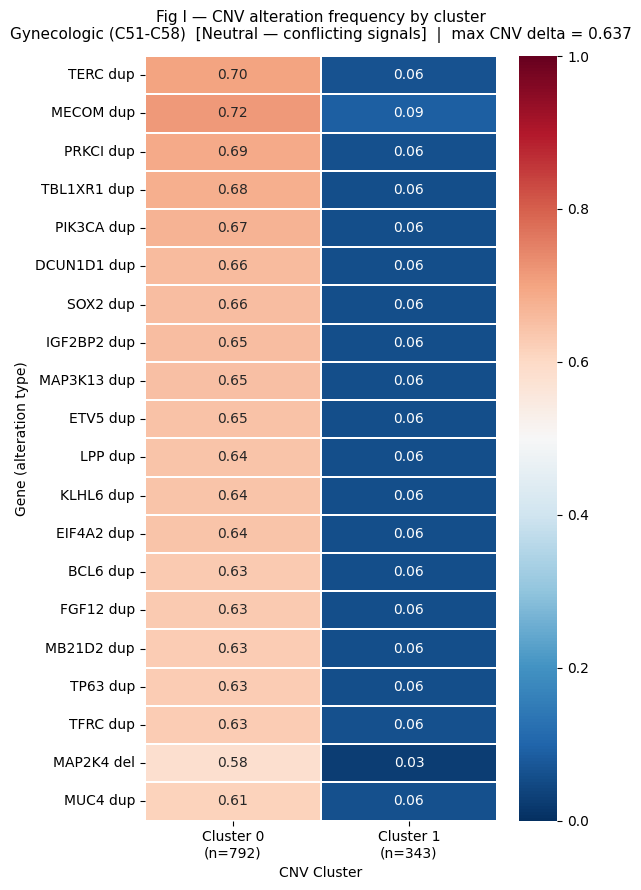

Saved: Gynecologic (C51-C58)  (max delta = 0.637)


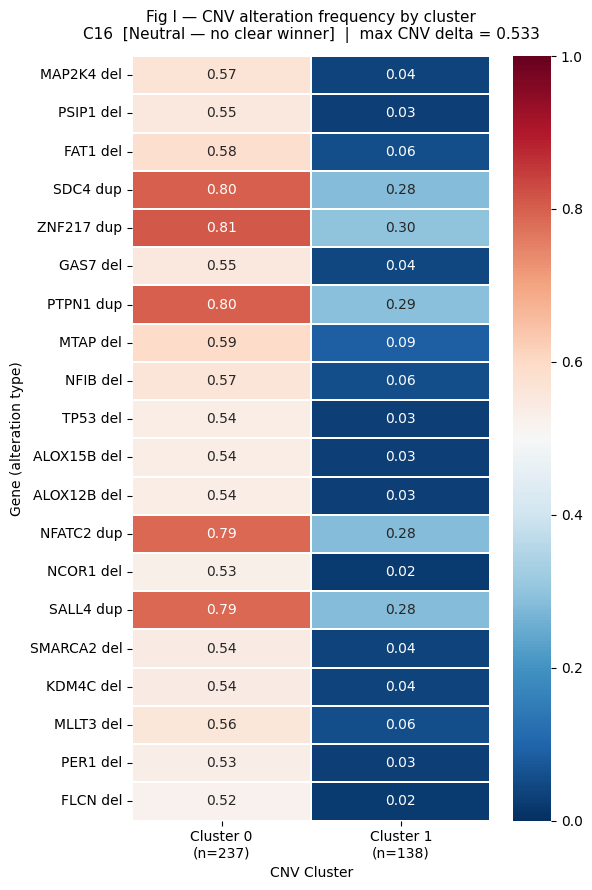

Saved: C16  (max delta = 0.533)


In [38]:
# Fig I — CNV heatmaps for multi-cluster neutral groups
for grp in neutral_multi:
    df_grp  = neutral_leiden_merged[grp]
    markers = neutral_diff_markers[grp]

    top_features = (
        markers
        .sort_values("delta", key=abs, ascending=False)
        .drop_duplicates("feature")
        .head(20)["feature"]
        .tolist()
    )
    max_delta = markers["delta"].abs().max()

    freq_mat = compute_freq_matrix(df_grp, top_features, cluster_col="cluster")
    freq_mat.index = [
        f.replace("cnv_", "").replace("__dup", " dup").replace("__del", " del")
        for f in freq_mat.index
    ]

    cluster_sizes = df_grp["cluster"].value_counts().sort_index()
    freq_mat.columns = [
        f"Cluster {c}\n(n={cluster_sizes[c]})" for c in freq_mat.columns
    ]

    fig, ax = plt.subplots(figsize=(max(6, freq_mat.shape[1] * 2.5), max(8, 20 * 0.45)))
    sns.heatmap(
        freq_mat,
        cmap="RdBu_r", center=0.5, vmin=0, vmax=1,
        annot=True, fmt=".2f", linewidths=0.3,
        ax=ax,
    )
    ax.set_title(
        f"Fig I — CNV alteration frequency by cluster\n"
        f"{grp}  [{NEUTRAL_GROUPS[grp]}]  |  max CNV delta = {max_delta:.3f}",
        fontsize=11, pad=12,
    )
    ax.set_xlabel("CNV Cluster")
    ax.set_ylabel("Gene (alteration type)")
    plt.tight_layout()
    plt.savefig(OUT_FIG / f"fig_I_heatmap_cnv_neutral_{safe_name(grp)}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {grp}  (max delta = {max_delta:.3f})")

In [39]:
#  MOFA signatures for neutral groups 
# Check if MOFA found significant factors for these groups
print("MOFA significant factors for neutral groups")
print("=" * 65)

neutral_mofa_sigs = {}
for grp in NEUTRAL_GROUPS:
    sigs = df_mofa_sig[df_mofa_sig["cancer_group"] == grp].copy()
    neutral_mofa_sigs[grp] = sigs
    if sigs.empty:
        print(f"\n  {grp:40s} → 0 significant MOFA factors")
    else:
        print(f"\n  {grp:40s} → {len(sigs)} significant factors")
        print(sigs[["factor", "cluster", "dominant_omic", "auc", "disc_power"]].to_string(index=False))

MOFA significant factors for neutral groups

  Gynecologic (C51-C58)                    → 86 significant factors
  factor  cluster dominant_omic      auc  disc_power
 Factor1        0           RNA 0.819531    0.319531
 Factor2        0          Meth 0.314951    0.185049
 Factor3        0          Meth 0.757329    0.257329
 Factor4        0           RNA 0.673782    0.173782
 Factor5        0           CNV 0.605936    0.105936
 Factor6        0           CNV 0.389069    0.110931
 Factor7        0           RNA 0.243487    0.256513
 Factor9        0          Meth 0.235498    0.264502
Factor10        0          Meth 0.274499    0.225501
Factor14        0           CNV 0.600898    0.100898
Factor15        0          Meth 0.668925    0.168925
Factor17        0           CNV 0.332660    0.167340
 Factor1        1           RNA 0.069072    0.430928
 Factor2        1          Meth 0.909270    0.409270
 Factor3        1          Meth 0.070784    0.429216
 Factor4        1           RNA 0.19566

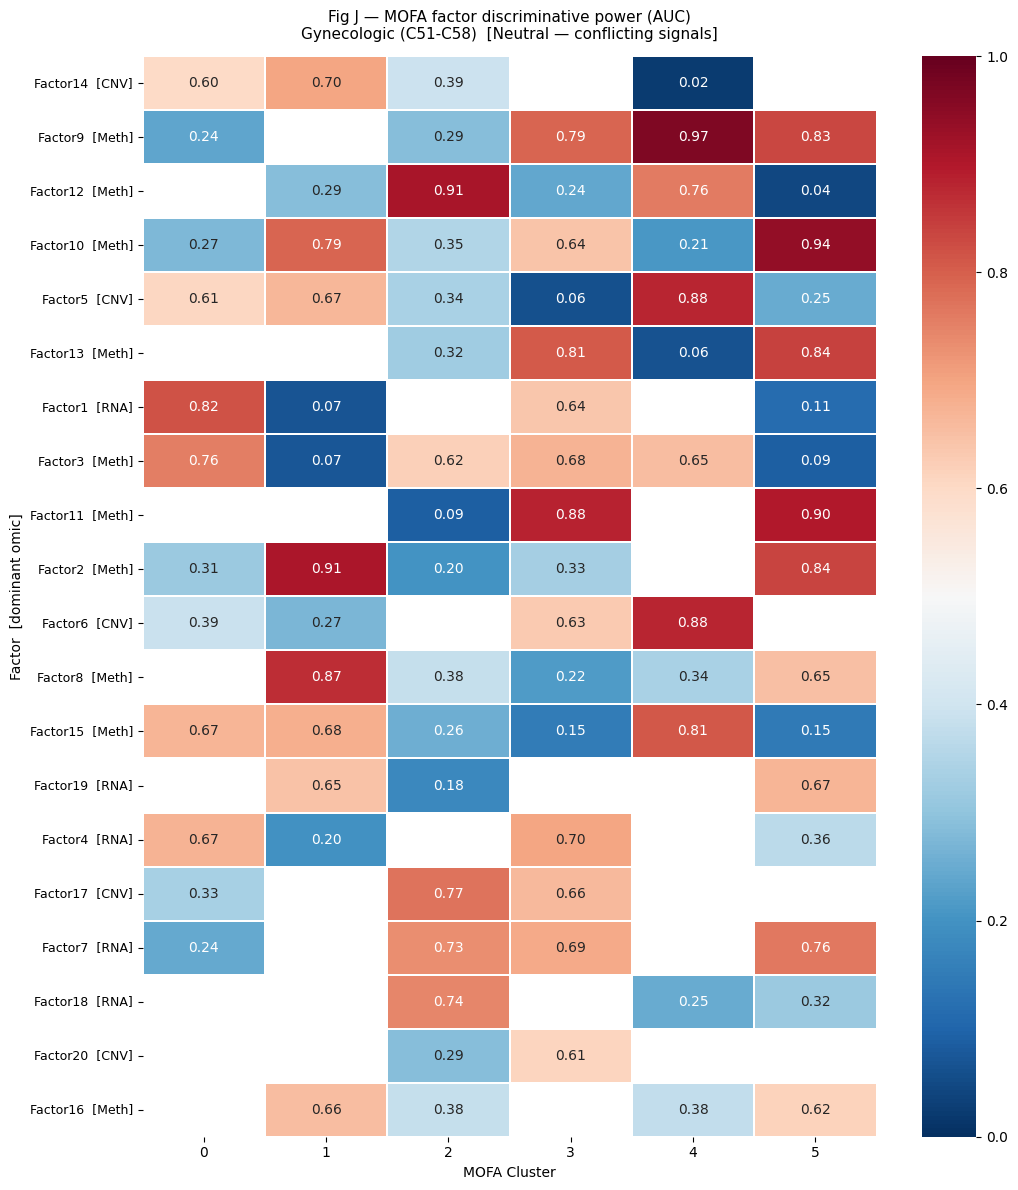

Saved: Gynecologic (C51-C58)
Skipping SoftTissue (C49) — no significant MOFA factors


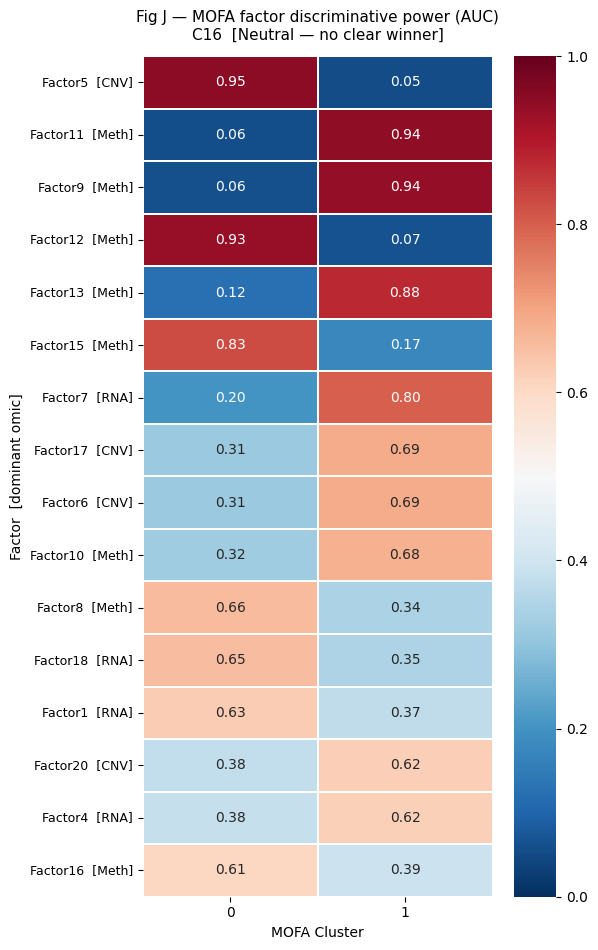

Saved: C16


In [40]:
# Fig J — MOFA AUC heatmaps for neutral groups 
# Only if significant factors exist
for grp, sigs in neutral_mofa_sigs.items():
    if sigs.empty:
        print(f"Skipping {grp} — no significant MOFA factors")
        continue

    pivot = sigs.pivot_table(index="factor", columns="cluster", values="auc")
    pivot["_max_disc"] = (pivot - 0.5).abs().max(axis=1)
    pivot = pivot.sort_values("_max_disc", ascending=False).drop(columns="_max_disc")

    factor_omic  = sigs.groupby("factor")["dominant_omic"].first()
    ytick_labels = [f"{f}  [{factor_omic.get(f, '?')}]" for f in pivot.index]

    fig, ax = plt.subplots(figsize=(max(6, pivot.shape[1] * 1.8), max(5, len(pivot) * 0.6)))
    sns.heatmap(
        pivot,
        cmap="RdBu_r", center=0.5, vmin=0, vmax=1,
        annot=True, fmt=".2f", linewidths=0.3,
        ax=ax,
    )
    ax.set_yticklabels(ytick_labels, fontsize=9)
    ax.set_title(
        f"Fig J — MOFA factor discriminative power (AUC)\n"
        f"{grp}  [{NEUTRAL_GROUPS[grp]}]",
        fontsize=11, pad=12,
    )
    ax.set_xlabel("MOFA Cluster")
    ax.set_ylabel("Factor  [dominant omic]")
    plt.tight_layout()
    plt.savefig(OUT_FIG / f"fig_J_mofa_auc_neutral_{safe_name(grp)}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {grp}")

In [41]:
# Top MOFA marker genes for neutral groups 
for grp, sigs in neutral_mofa_sigs.items():
    if sigs.empty:
        continue

    print(f"\n{'='*65}")
    print(f"GROUP: {grp}  [{NEUTRAL_GROUPS[grp]}]")
    print(f"{'='*65}")

    sigs_sorted = sigs.sort_values("disc_power", ascending=False)

    for _, row in sigs_sorted.iterrows():
        factor    = row["factor"]
        omic      = row["dominant_omic"]
        cluster   = row["cluster"]
        auc       = row["auc"]
        direction = "↑" if row["auc"] > 0.5 else "↓"

        df_W = W_map.get(omic)
        if df_W is None or factor not in df_W.columns:
            continue

        top_genes = get_top_loadings(df_W, factor, top_n=10)
        print(f"\n  Cluster {cluster} | {factor} | {omic} | AUC={auc:.3f} {direction}")
        for _, g in top_genes.iterrows():
            sign = "+" if g["loading"] > 0 else "-"
            print(f"    {sign} {g['feature']:40s}  |W|={g['abs_loading']:.4f}")


GROUP: Gynecologic (C51-C58)  [Neutral — conflicting signals]

  Cluster 4 | Factor14 | CNV | AUC=0.022 ↓
    + IRS1__dup_CNV                             |W|=0.1475
    + INPP5D__dup_CNV                           |W|=0.1466
    + CUL3__dup_CNV                             |W|=0.1460
    + SP140__dup_CNV                            |W|=0.1451
    + PAX3__dup_CNV                             |W|=0.1443
    + CREB1__dup_CNV                            |W|=0.1435
    + TPM4__dup_CNV                             |W|=0.1428
    + KLF2__dup_CNV                             |W|=0.1427
    + HDAC4__dup_CNV                            |W|=0.1422
    + ATIC__dup_CNV                             |W|=0.1421

  Cluster 4 | Factor9 | Meth | AUC=0.967 ↑
    + EXT1_Meth                                 |W|=0.3292
    + HOXA3_Meth                                |W|=0.2793
    + SNX29_Meth                                |W|=0.2772
    + MPL_Meth                                  |W|=0.2687
    + CTNND1_Meth      